In [2]:
from common import *
from collections import defaultdict
from uncertainties import ufloat
from scipy import stats
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns
from sklearn import metrics

get(
    "machinable.index",
    "./index",
).__enter__()

machinable.index [1e798e]

# Surrogate optimization vs. baselines

In [14]:
_ca1_sopt_baseline = get("interface._ca1_sopt_baseline", {"selection": (None,)})

globus_download(_ca1_sopt_baseline)

In [ ]:
baseline_hvs = defaultdict(dict)
nos_hv = defaultdict(list)
igds = defaultdict(dict)
nadirs = {}


def _name(experiment):
    n = (
        experiment.label()
        .split("_neuron::")[-1][2:]
        .split("/")[0]
        .replace("joint-", "")
    )
    if "o" in n:
        n += (
            "-"
            + experiment.config.dopt_params.surrogate_custom_training_kwargs.backbone
        )
    return n


for p in _ca1_sopt_baseline.populations():
    experiments = _ca1_sopt_baseline.components.filter(
        lambda x: p in x.label() and not x.load_attribute("preflight", False)
    )
    nadir = nadirs[p] = fronts_nadir(experiments)
    tracking = {"interfaces": []}

    for experiment in experiments:
        model_name = _name(experiment)

        epoch_ranges = experiment.epoch_ranges(from_zero=True)

        if model_name == "-":
            tracking["interfaces"].append(experiment)
            continue

        if model_name == "gpr":
            tracking["ranges"] = epoch_ranges

        baseline_hvs[p].setdefault(model_name, {})
        for epoch, region in enumerate(epoch_ranges):
            baseline_hvs[p][model_name].setdefault(str(epoch), [])
            hv = experiment.norm_hv_region(nadir, region)
            baseline_hvs[p][model_name][str(epoch)].append(hv)

    # backfill eval-normalized baseline
    baseline_hvs[p]["baseline"] = {}
    for epoch, region in enumerate(tracking["ranges"]):
        baseline_hvs[p]["baseline"][str(epoch)] = [
            i.norm_hv_region(nadir, region) for i in tracking["interfaces"]
        ]

    # compute nos hv after 25 epochs
    for i in tracking["interfaces"]:
        nos_hv[p + "10"].append(
            i.norm_hv_region(nadir, i.epoch_ranges(from_zero=True)[10])
        )
        nos_hv[p].append(i.norm_hv(nadir))

    # compute igds
    for experiment in experiments:
        model_name = _name(experiment)
        igds[p][model_name] = [float(experiment.igd(i)) for i in tracking["interfaces"]]

IVY
PVBC
CCKBC
AAC
IS
SCA
BS
OLM
NGFC


In [5]:
initial_samples = {
    p: _ca1_sopt_baseline.components.filter(
        lambda x: p in x.label() and not x.load_attribute("preflight", False)
    )
    .first()
    .num_initial_samples
    for p in _ca1_sopt_baseline.populations()
}

In [6]:
initial_samples

{'IVY': 1200,
 'PVBC': 1200,
 'CCKBC': 1200,
 'AAC': 1200,
 'IS': 1100,
 'SCA': 1500,
 'BS': 1200,
 'OLM': 1200,
 'NGFC': 1300}

In [8]:
nadirs

{'IVY': [20047.375, 21434.48046875, 1537.0, 373.1077880859375],
 'PVBC': [350261.03125,
  999.601806640625,
  2969.741455078125,
  2248.458740234375],
 'CCKBC': [52868.2890625, 428839.78125, 10206.0, 2269.830078125],
 'AAC': [2508.93505859375, 12411.75, 6420.60009765625, 1842.2513427734375],
 'IS': [9628.4677734375, 12268.6865234375, 8687.5390625, 1204.2523193359375],
 'SCA': [149966.625, 537732.0, 3595.0625, 943.1060791015625],
 'BS': [36818.7421875, 1115.2860107421875, 6611.66650390625, 2771.15087890625],
 'OLM': [217443.796875, 296473.375, 11709.0, 2251.440185546875],
 'NGFC': [237959.21875, 6404.2978515625, 31567.064453125, 1716.8248291015625]}

In [7]:
stash("figure3-nos_hv", nos_hv)
stash("figure3-nadirs", nadirs)
stash("figure3-baseline_hvs", baseline_hvs)
stash("figure3-igds", igds)
stash("figure3-initial_samples", initial_samples)

In [3]:
nadirs = restore("figure3-nadirs")
nos_hv = restore("figure3-nos_hv")
baseline_hvs = restore("figure3-baseline_hvs")
igds = restore("figure3-igds")
initial_samples = restore("figure3-initial_samples")

/tmp/ipykernel_2862614/332768701.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


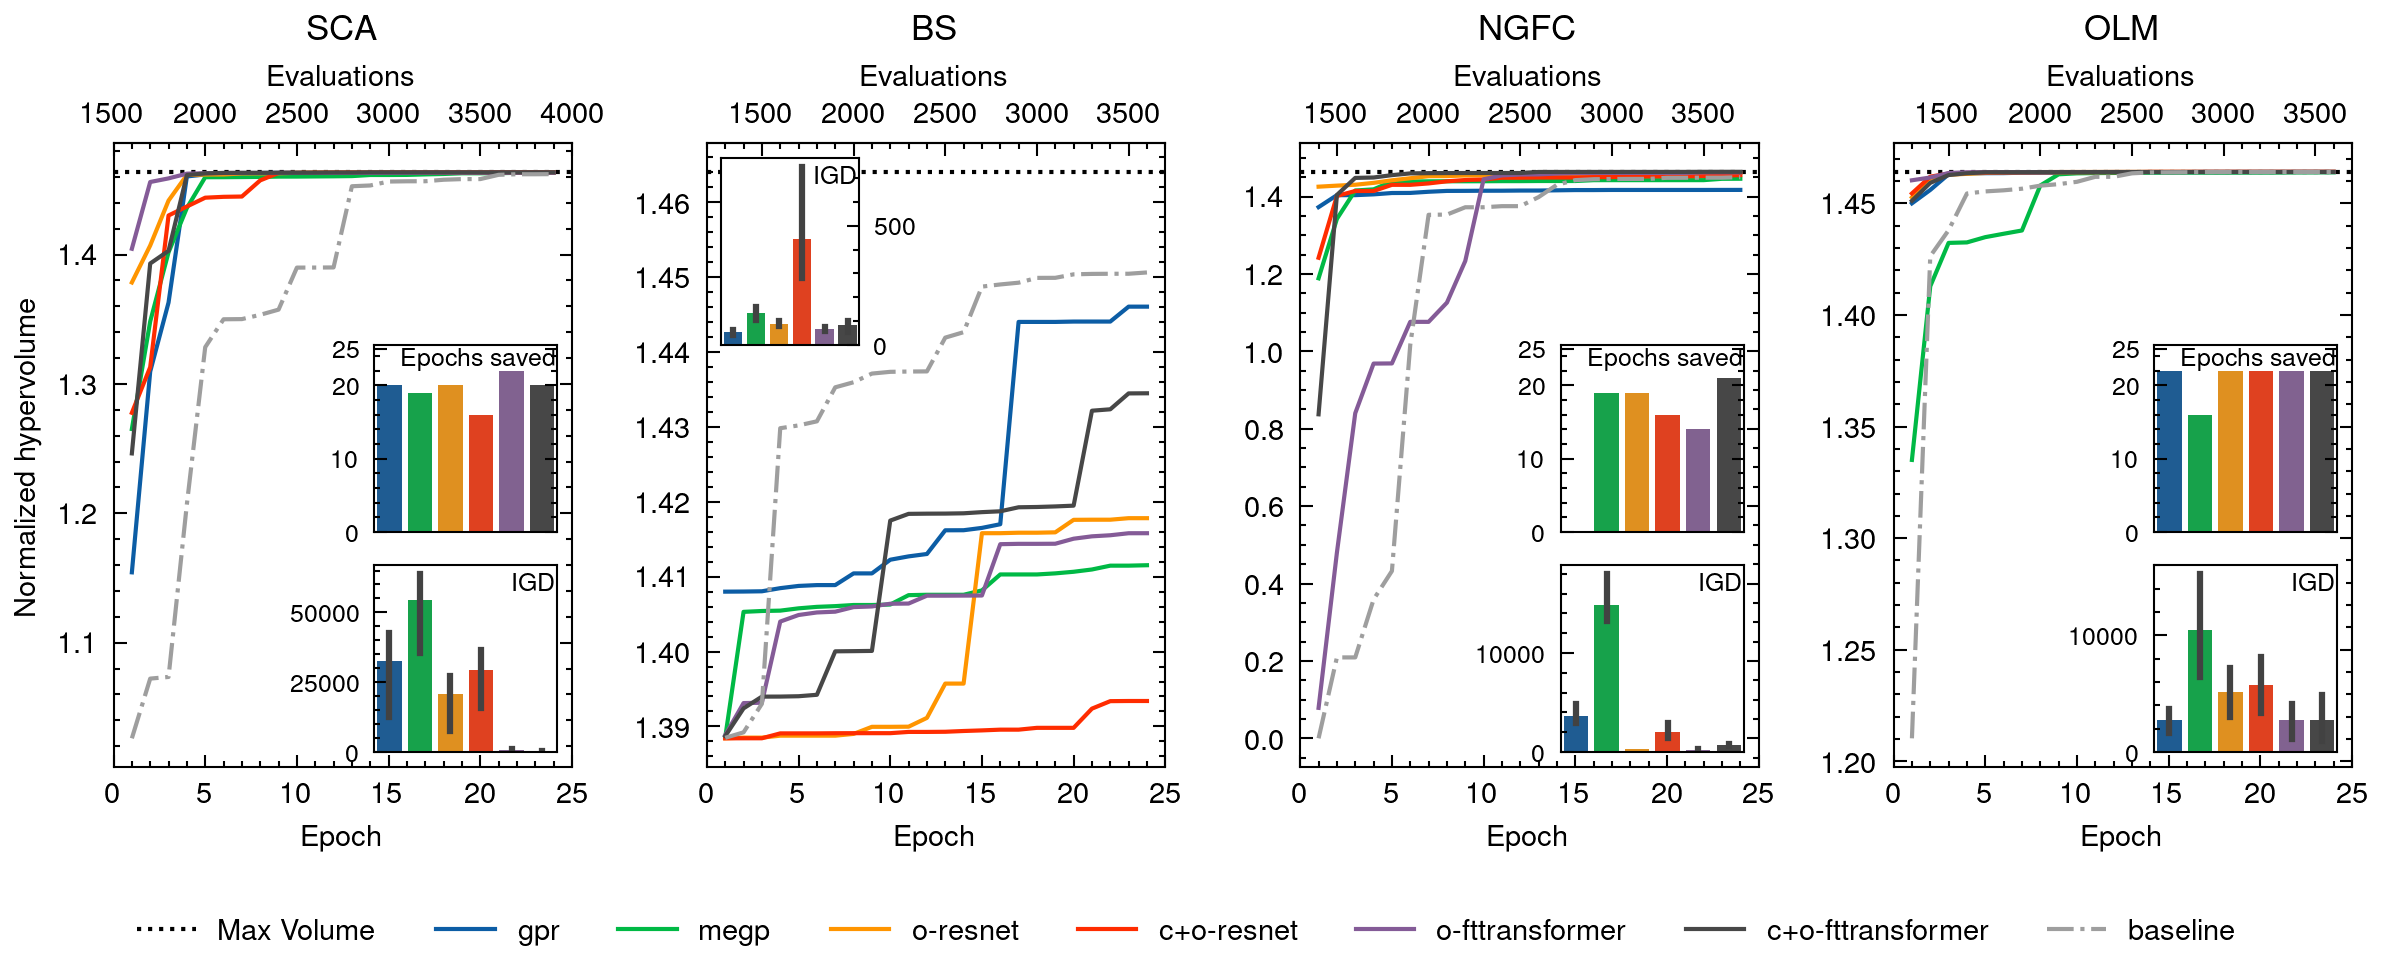

In [154]:
plt.rcParams["xtick.top"] = False
plt.rcParams["ytick.left"] = True
plt.rcParams["ytick.right"] = True
# plt.rcParams['axes.spines.top'] = False

selection = ["SCA", "BS", "NGFC", "OLM"]

fig, axs = plt.subplots(1, len(selection), figsize=(8, 3), sharey=False)

for ax, (p, models) in zip(
    axs.flatten(), {key: baseline_hvs[key] for key in selection}.items()
):
    nos_mean = np.mean(nos_hv[p + "10"])
    nos_err = stats.sem(nos_hv[p + "10"])

    ax.axhline(y=1.1**4, color="black", linestyle=":", label="Max Volume")

    # determine when surrogate reaches within 1% of non-surrogate HV
    converged = {}
    for i, (model_name, epoch_hvs) in enumerate(models.items()):
        for epoch, hvs in epoch_hvs.items():
            epoch = int(epoch)
            converged[model_name] = [0]
            if epoch > 1 and np.mean(hvs) > 0.99 * np.mean(
                baseline_hvs[p]["baseline"]["24"]
            ):
                converged[model_name] = [24 - epoch]
                break

    for i, (model_name, epoch_hvs) in enumerate(models.items()):
        x = []
        y = []
        y_err = []
        yy = defaultdict(list)
        y_all = []
        for epoch, hvs in epoch_hvs.items():
            epoch = int(epoch)
            y_all.append(np.mean(hvs))
            if epoch == 0 or epoch > 100:
                continue
            x.append(int(epoch))
            y.append(np.mean(hvs))
            y_err.append(stats.sem(hvs))
            for q in range(len(hvs)):
                yy[q].append(hvs[q])

        y_err = np.array(y_err)
        y = np.array(y)

        label = model_name  # str(ufloat(y[-1], y_err[-1]) / ufloat(nos_mean, nos_err) * 100) + '%'

        if "o-" in model_name and "c+o" not in model_name:
            pass

        # ax.errorbar(x, y, yerr=y_err, label=model_name + f" ({ufloat(y[-1], y_err[-1])})", linestyle='-', capsize=1)
        ax.plot(
            x,
            y,
            color=icolors[i],
            label=label,
            linestyle="-" if model_name != "baseline" else "dashdot",
        )
        # for trial, points in yy.items():
        #     ax.scatter(x, points, color=icolors[i])
        # ax.fill_between(x, y-y_err, y+y_err, alpha=0.05, color=icolors[i])

    # igd
    axigd = inset_axes(
        ax,
        width="40%" if p != "BS" else "30%",
        height="30%" if p != "BS" else "30%",
        loc=f"lower right" if p != "BS" else "upper left",
    )
    sns.barplot(pd.DataFrame(igds[p]).drop("-", axis=1), ax=axigd)
    axigd.set_title("IGD", loc="right", y=1.0, pad=-6, fontsize=6)
    axigd.tick_params(top=False, bottom=False, left=True, right=True, labelsize=6)
    axigd.set_xticks([])
    axigd
    if p == "BS":
        axigd.yaxis.tick_right()
        axigd.yaxis.set_label_position("right")
    else:
        axigd.yaxis.tick_left()
        axigd.yaxis.set_label_position("left")

    # savings
    if p != "BS":
        axsave = inset_axes(
            ax,
            width="40%",
            height="30%",
            loc=f"upper right",
            bbox_to_anchor=(0, -0.3, 1, 1),
            bbox_transform=ax.transAxes,
        )
        sns.barplot(pd.DataFrame(converged).drop("baseline", axis=1), ax=axsave)
        axsave.set_title("Epochs saved", loc="right", y=1.0, pad=-5, fontsize=6)
        axsave.tick_params(top=False, bottom=False, left=True, right=True, labelsize=6)
        axsave.set_xticks([])
        axsave.set_ylim([0, 25.5])
        axsave.set_yticks([0, 10, 20, 25])

    # ax.axhline(y=nos_mean, color="red", linestyle=":", label=f"NoS ({ufloat(nos_mean, nos_err)})")
    # ax.fill_between(x, [nos_mean - nos_err] * len(x), [nos_mean + nos_err] * len(x), color="red", alpha=0.1)

    # ax.set_xscale('log')
    # ax.set_yscale('log')
    ax.set_xlabel("Epoch")
    ax.set_xlim([0, 25])

    # ax.legend(loc='best')
    ax.tick_params(top=False)

    secax = ax.secondary_xaxis(
        "top",
        functions=(
            lambda x, ins=initial_samples[p]: x * 100 + ins,
            lambda x, ins=initial_samples[p]: (x + ins) / 100,
        ),
    )
    secax.set_xlabel("Evaluations")

    # ax.set_ylim(0, 1.1**4 * 1.05)
    ax.set_title(
        p,
    )  # loc='left', y=1.0, pad=-6)

axs[0].set_ylabel("Normalized hypervolume")

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=len(labels), bbox_to_anchor=(0.95, -0.01))
plt.tight_layout()
plt.show()

In [64]:
stash("figure3-hypervolumes", fig)

In [4]:
# add motoneuron
nadirs.update(restore("figure4-nadirs"))
nos_hv.update(restore("figure4-nos_hv"))
baseline_hvs.update(restore("figure4-baseline_hvs"))
igds.update(restore("figure4-igds"))
initial_samples.update(restore("figure4-initial_samples"))

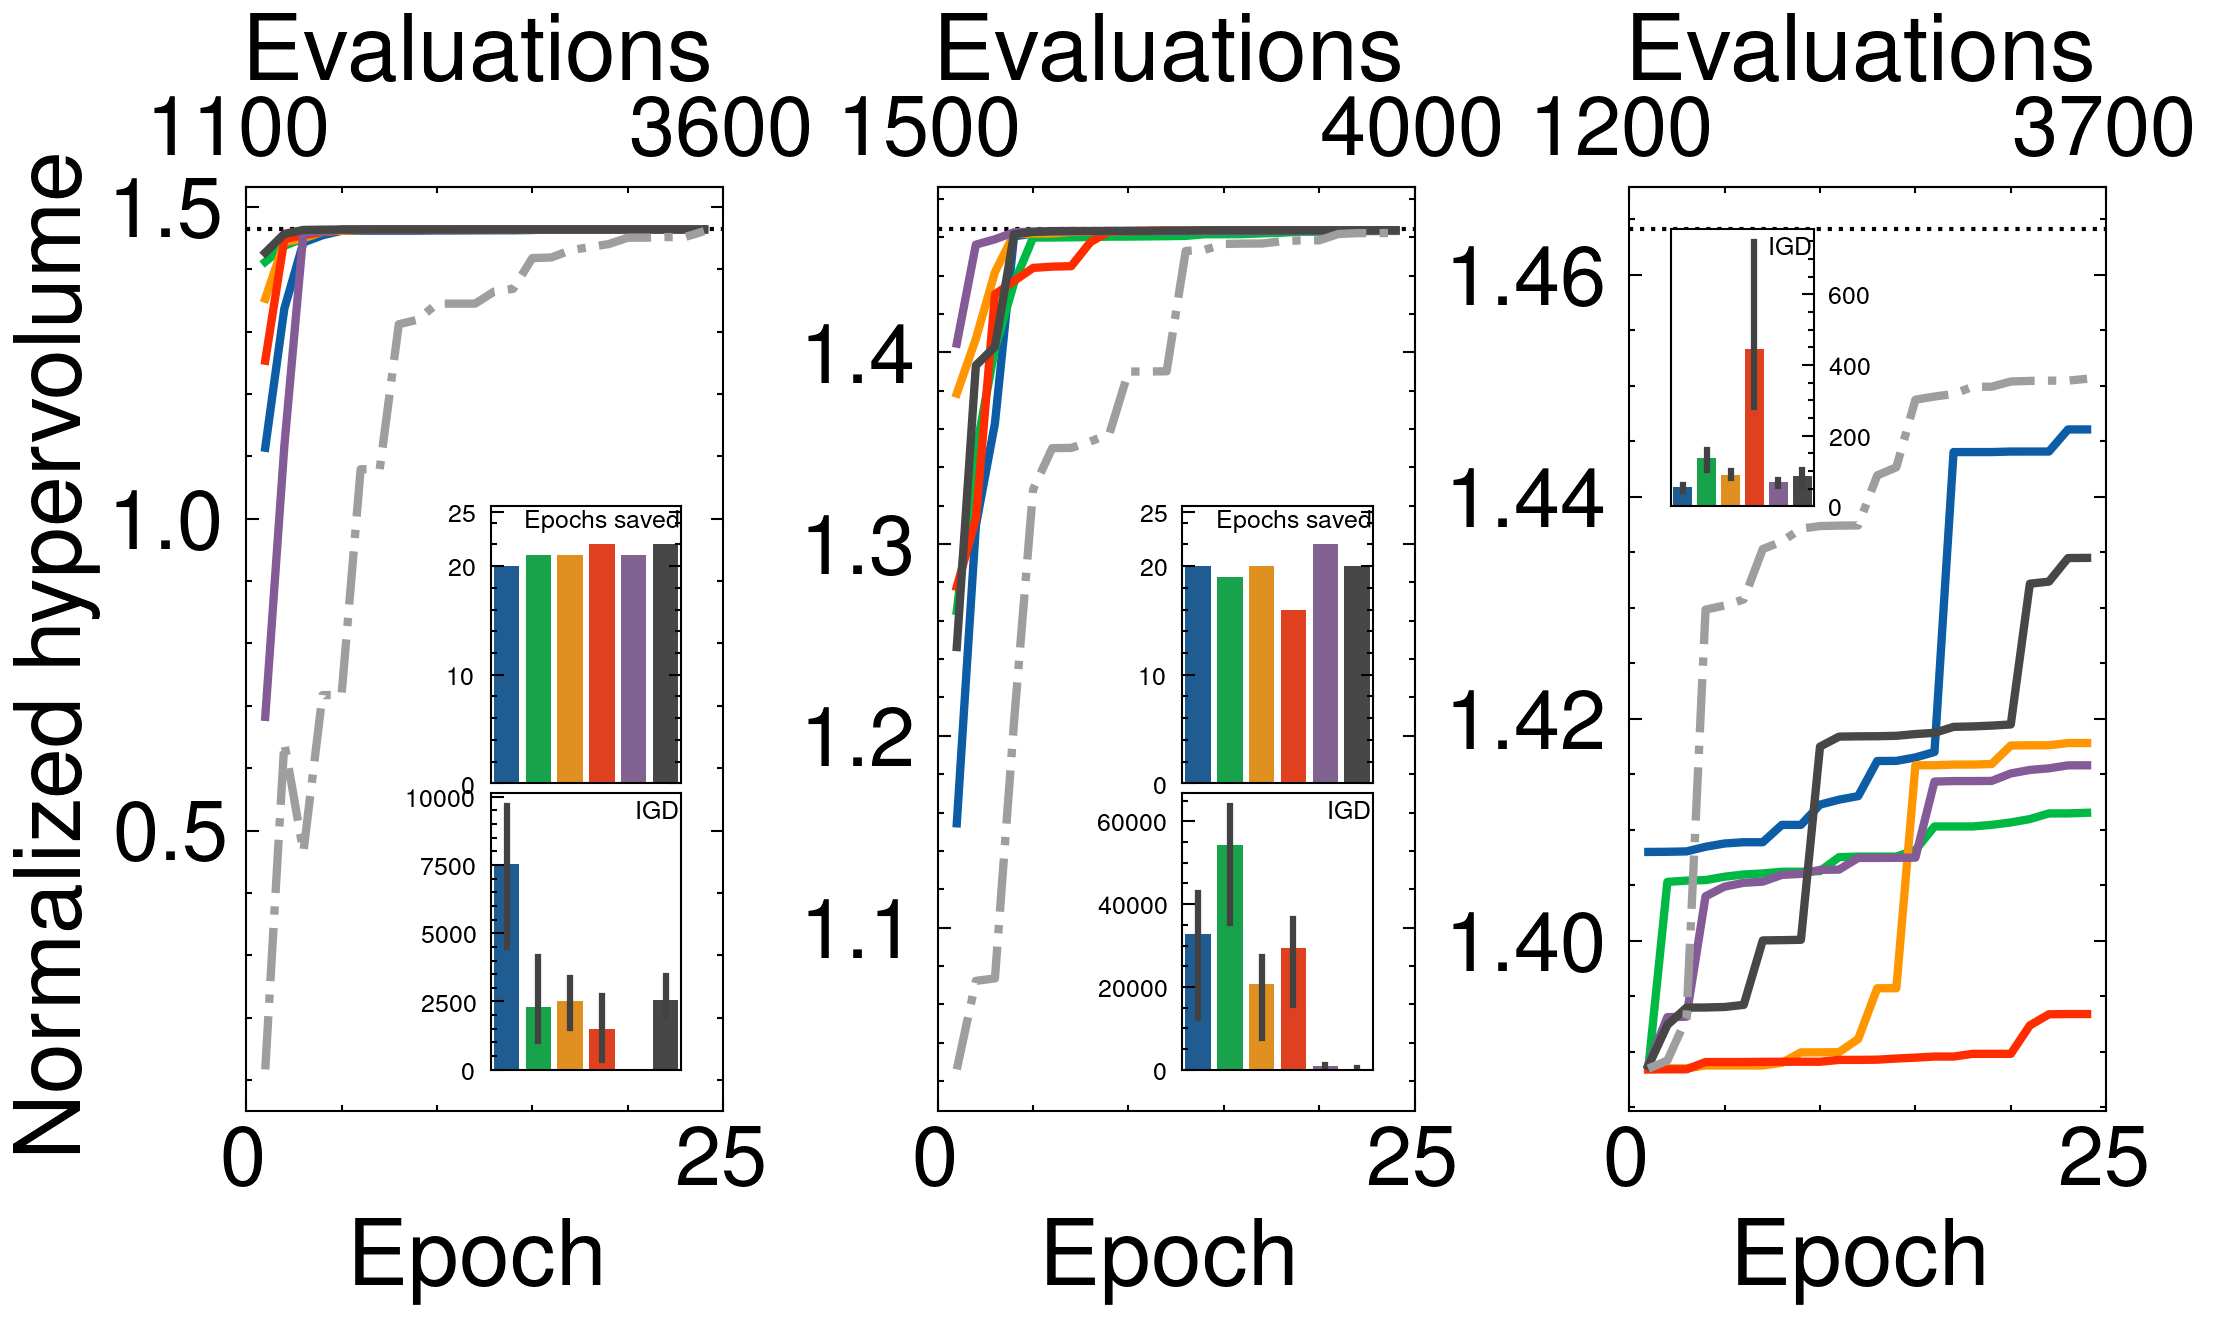

In [35]:

with rc_context():

    plt.rcParams["xtick.top"] = False
    plt.rcParams["ytick.left"] = True
    plt.rcParams["ytick.right"] = True
    # plt.rcParams['axes.spines.top'] = False

    selection = ["MN", "SCA", "BS"]

    fig, axs = plt.subplots(1, len(selection), figsize=(8, 4), sharey=False)
    fig.subplots_adjust(wspace=0.45)

    for ax, (p, models) in zip(
        axs.flatten(), {key: baseline_hvs[key] for key in selection}.items()
    ):
        nos_mean = np.mean(nos_hv[p + "10"])
        nos_err = stats.sem(nos_hv[p + "10"])

        ax.axhline(y=1.1**4, color="black", linestyle=":", label="Max Volume")

        # determine when surrogate reaches within 1% of non-surrogate HV
        converged = {}
        for i, (model_name, epoch_hvs) in enumerate(models.items()):
            for epoch, hvs in epoch_hvs.items():
                epoch = int(epoch)
                converged[model_name] = [0]
                if epoch > 1 and np.mean(hvs) > 0.99 * np.mean(
                    baseline_hvs[p]["baseline"]["24"]
                ):
                    converged[model_name] = [24 - epoch]
                    break

        for i, (model_name, epoch_hvs) in enumerate(models.items()):
            x = []
            y = []
            y_err = []
            yy = defaultdict(list)
            y_all = []
            for epoch, hvs in epoch_hvs.items():
                epoch = int(epoch)
                y_all.append(np.mean(hvs))
                if epoch == 0 or epoch > 100:
                    continue
                x.append(int(epoch))
                y.append(np.mean(hvs))
                y_err.append(stats.sem(hvs))
                for q in range(len(hvs)):
                    yy[q].append(hvs[q])

            y_err = np.array(y_err)
            y = np.array(y)

            label = model_name  # str(ufloat(y[-1], y_err[-1]) / ufloat(nos_mean, nos_err) * 100) + '%'

            if "o-" in model_name and "c+o" not in model_name:
                pass

            # ax.errorbar(x, y, yerr=y_err, label=model_name + f" ({ufloat(y[-1], y_err[-1])})", linestyle='-', capsize=1)
            ax.plot(
                x,
                y,
                color=icolors[i],
                label=label,
                linestyle="-" if model_name != "baseline" else "dashdot",
                linewidth=2
            )
            # for trial, points in yy.items():
            #     ax.scatter(x, points, color=icolors[i])
            # ax.fill_between(x, y-y_err, y+y_err, alpha=0.05, color=icolors[i])

        # igd
        axigd = inset_axes(
            ax,
            width="40%" if p != "BS" else "30%",
            height="30%" if p != "BS" else "30%",
            loc=f"lower right" if p != "BS" else "upper left",
        )
        sns.barplot(pd.DataFrame(igds[p]).drop("-", axis=1), ax=axigd)
        axigd.set_title("IGD", loc="right", y=1.0, pad=-6, fontsize=6)
        axigd.tick_params(top=False, bottom=False, left=True, right=True, labelsize=6)
        axigd.set_xticks([])
        axigd
        if p == "BS":
            axigd.yaxis.tick_right()
            axigd.yaxis.set_label_position("right")
        else:
            axigd.yaxis.tick_left()
            axigd.yaxis.set_label_position("left")

        # savings
        if p != "BS":
            axsave = inset_axes(
                ax,
                width="40%",
                height="30%",
                loc=f"upper right",
                bbox_to_anchor=(0, -0.3, 1, 1),
                bbox_transform=ax.transAxes,
            )
            sns.barplot(pd.DataFrame(converged).drop("baseline", axis=1), ax=axsave)
            axsave.set_title("Epochs saved", loc="right", y=1.0, pad=-5, fontsize=6)
            axsave.tick_params(top=False, bottom=False, left=True, right=True, labelsize=6)
            axsave.set_xticks([])
            axsave.set_ylim([0, 25.5])
            axsave.set_yticks([0, 10, 20, 25])

        # ax.axhline(y=nos_mean, color="red", linestyle=":", label=f"NoS ({ufloat(nos_mean, nos_err)})")
        # ax.fill_between(x, [nos_mean - nos_err] * len(x), [nos_mean + nos_err] * len(x), color="red", alpha=0.1)

        # ax.set_xscale('log')
        # ax.set_yscale('log')
        ax.set_xlabel("Epoch")
        ax.set_xlim([0, 25])

        # ax.legend(loc='best')
        ax.tick_params(top=False)

        secax = ax.secondary_xaxis(
            "top",
            functions=(
                lambda x, ins=initial_samples[p]: x * 100 + ins,
                lambda x, ins=initial_samples[p]: (x + ins) / 100,
            ),
        )
        secax.set_xlabel("Evaluations")
        min_evals = initial_samples[p]
        max_evals = int(ax.get_xlim()[1] * 100 + initial_samples[p])
        secax.set_xlim(min_evals, max_evals)
        secax.set_xticks([min_evals, max_evals])

        # ax.set_ylim(0, 1.1**4 * 1.05)
        # ax.set_title(
        #     p,
        # )  # loc='left', y=1.0, pad=-6)

    axs[0].set_ylabel("Normalized hypervolume")

    handles, labels = axs[0].get_legend_handles_labels()
    #fig.legend(handles, labels, ncol=len(labels)//2, bbox_to_anchor=(0.95, -0.01))
    #plt.tight_layout()
    plt.show()

In [36]:
stash("figure3-hv-convergence-top-3", fig)

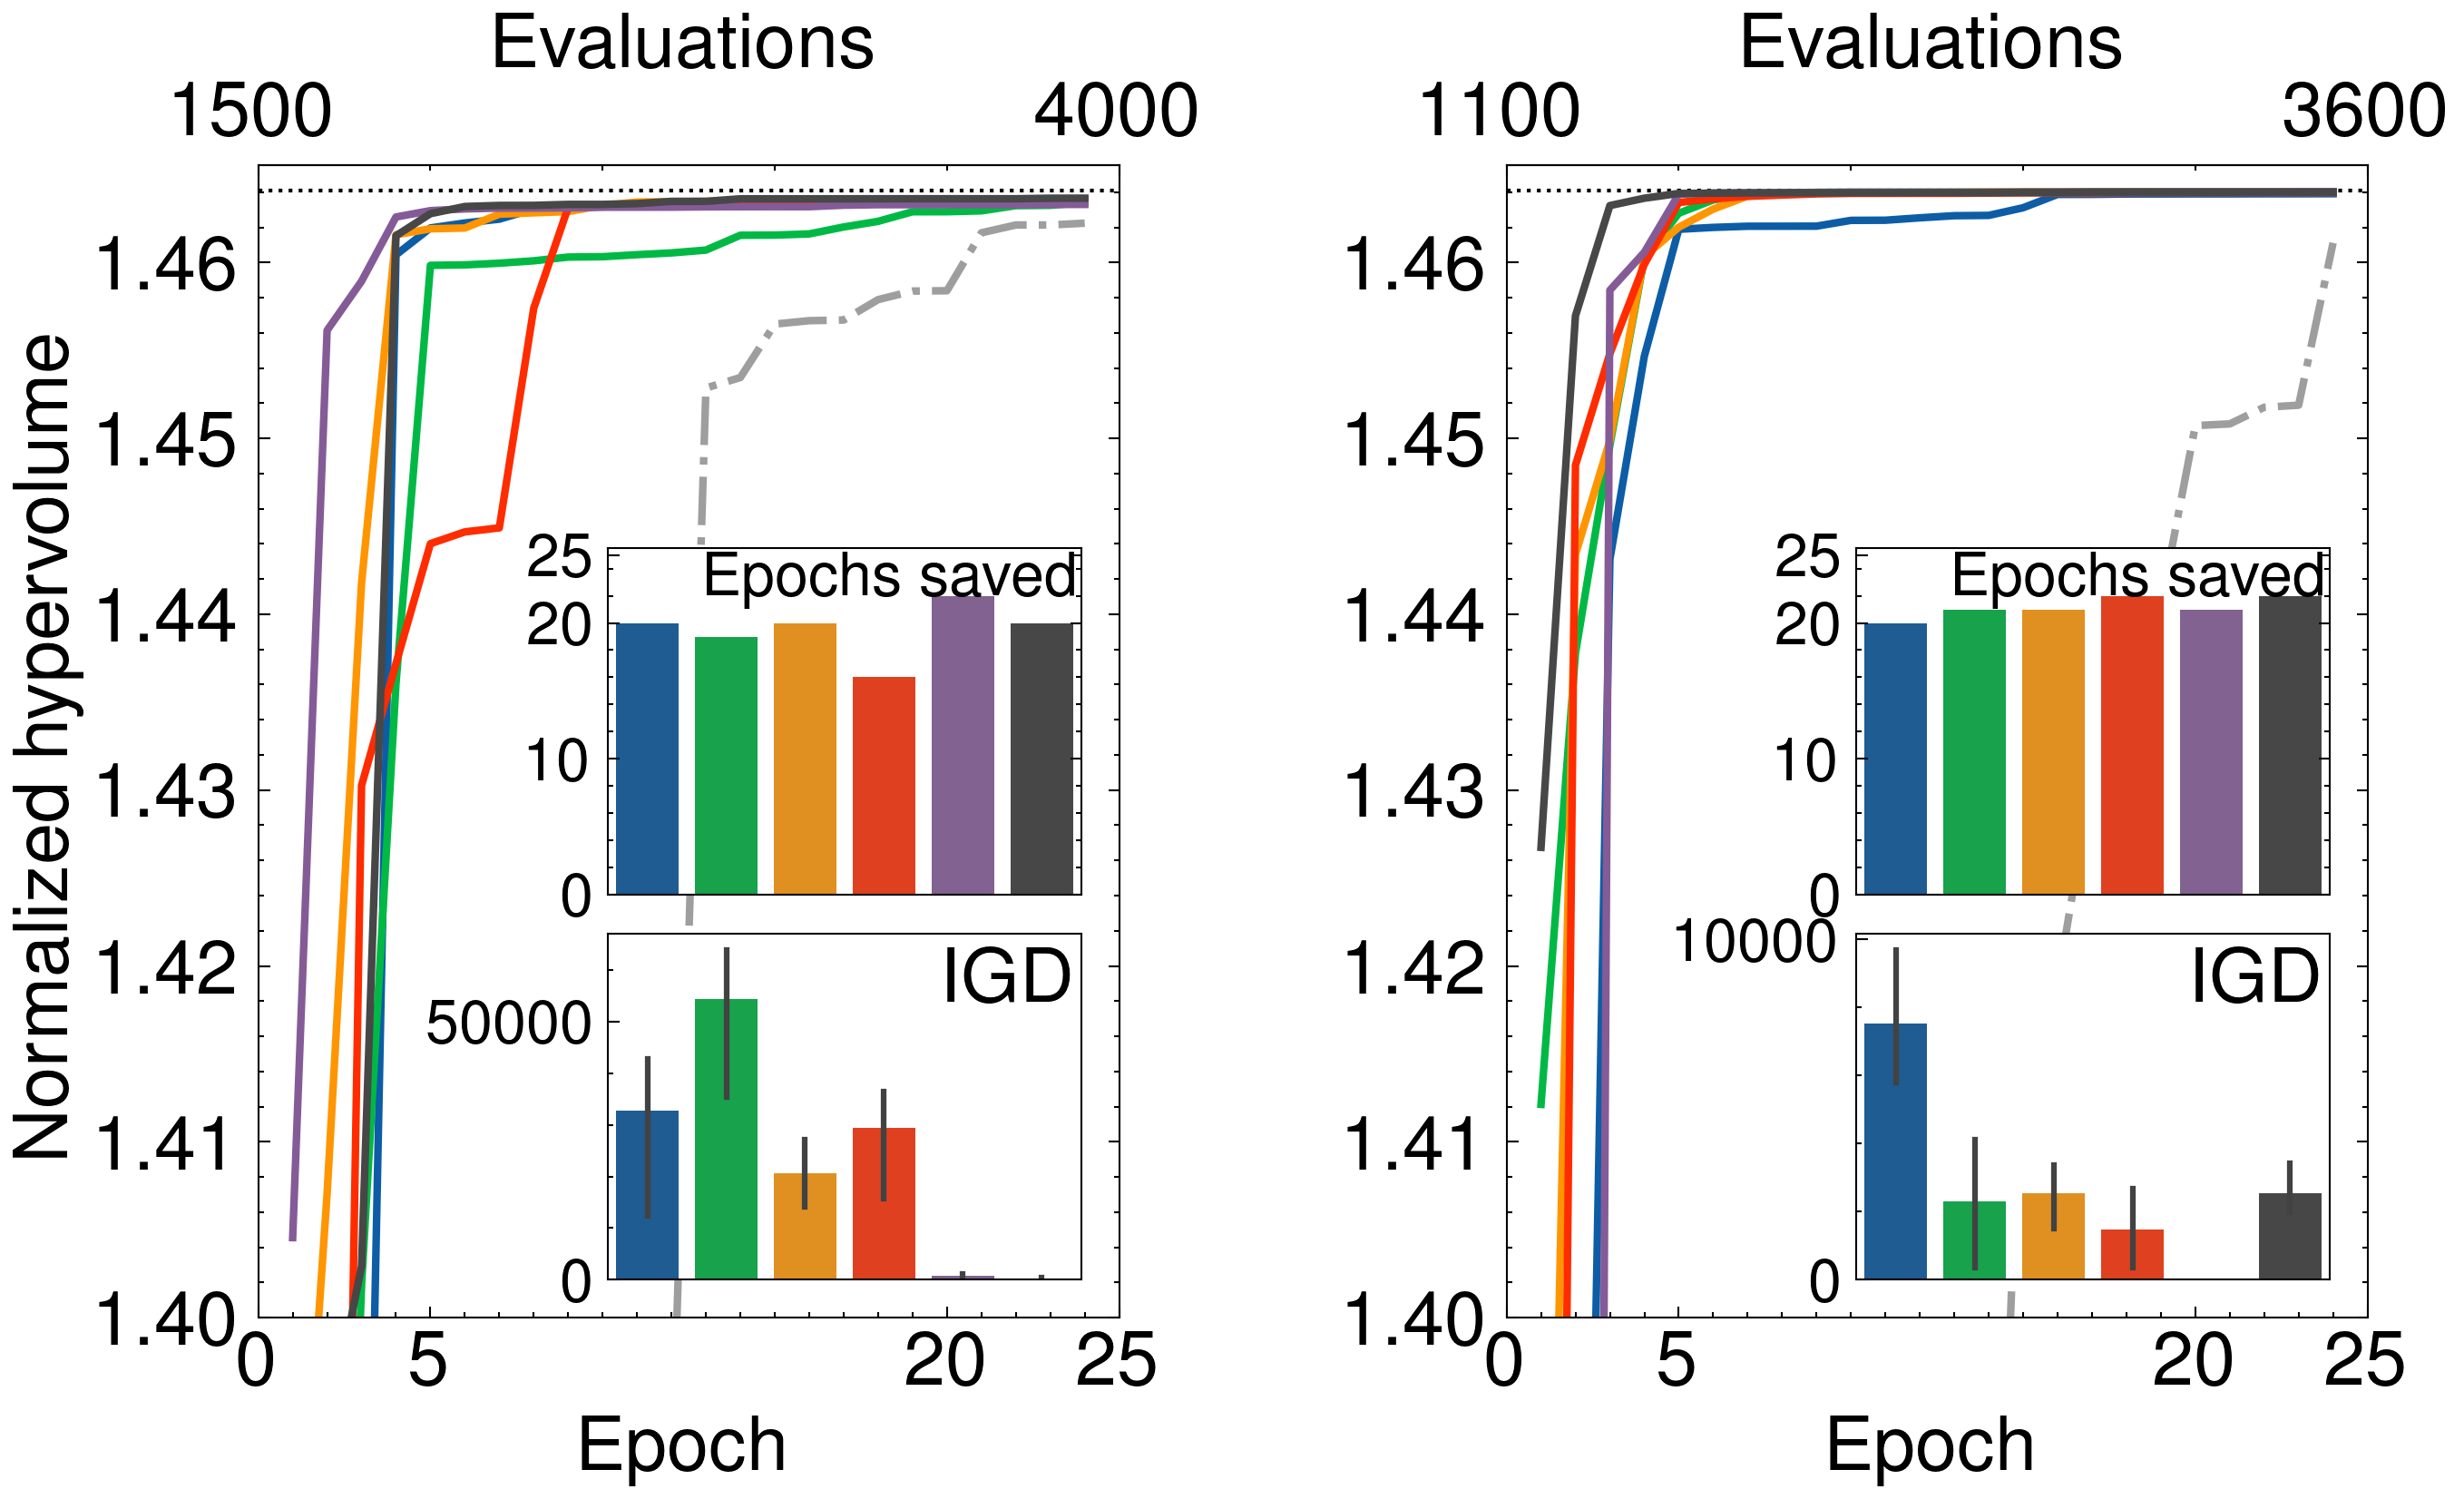

In [47]:

with rc_context():

    plt.rcParams["xtick.top"] = False
    plt.rcParams["ytick.left"] = True
    plt.rcParams["ytick.right"] = True
    # plt.rcParams['axes.spines.top'] = False

    selection = [ "SCA", "MN"]

    fig, axs = plt.subplots(1, len(selection), figsize=(10, 5.5), sharey=False)
    fig.subplots_adjust(wspace=0.45)

    for ax, (p, models) in zip(
        axs.flatten(), {key: baseline_hvs[key] for key in selection}.items()
    ):
        nos_mean = np.mean(nos_hv[p + "10"])
        nos_err = stats.sem(nos_hv[p + "10"])

        ax.axhline(y=1.1**4, color="black", linestyle=":", label="Max Volume")

        # determine when surrogate reaches within 1% of non-surrogate HV
        converged = {}
        for i, (model_name, epoch_hvs) in enumerate(models.items()):
            for epoch, hvs in epoch_hvs.items():
                epoch = int(epoch)
                converged[model_name] = [0]
                if epoch > 1 and np.mean(hvs) > 0.99 * np.mean(
                    baseline_hvs[p]["baseline"]["24"]
                ):
                    converged[model_name] = [24 - epoch]
                    break

        for i, (model_name, epoch_hvs) in enumerate(models.items()):
            x = []
            y = []
            y_err = []
            yy = defaultdict(list)
            y_all = []
            for epoch, hvs in epoch_hvs.items():
                epoch = int(epoch)
                y_all.append(np.mean(hvs))
                if epoch == 0 or epoch > 100:
                    continue
                x.append(int(epoch))
                y.append(np.mean(hvs))
                y_err.append(stats.sem(hvs))
                for q in range(len(hvs)):
                    yy[q].append(hvs[q])

            y_err = np.array(y_err)
            y = np.array(y)

            label = model_name  # str(ufloat(y[-1], y_err[-1]) / ufloat(nos_mean, nos_err) * 100) + '%'

            if "o-" in model_name and "c+o" not in model_name:
                pass

            # ax.errorbar(x, y, yerr=y_err, label=model_name + f" ({ufloat(y[-1], y_err[-1])})", linestyle='-', capsize=1)
            ax.plot(
                x,
                y,
                color=icolors[i],
                label=label,
                linestyle="-" if model_name != "baseline" else "dashdot",
                linewidth=2
            )
            # for trial, points in yy.items():
            #     ax.scatter(x, points, color=icolors[i])
            # ax.fill_between(x, y-y_err, y+y_err, alpha=0.05, color=icolors[i])

        # igd
        axigd = inset_axes(
            ax,
            width="55%" if p != "BS" else "30%",
            height="30%" if p != "BS" else "30%",
            loc=f"lower right" if p != "BS" else "upper left",
        )
        sns.barplot(pd.DataFrame(igds[p]).drop("-", axis=1), ax=axigd)
        axigd.set_title("IGD", loc="right", y=0.87, pad=-6, 
                        fontsize=20)
        axigd.tick_params(top=False, bottom=False, left=True, right=True, 
                          labelsize=16)
        axigd.set_xticks([])
        axigd
        if p == "BS":
            axigd.yaxis.tick_right()
            axigd.yaxis.set_label_position("right")
        else:
            axigd.yaxis.tick_left()
            axigd.yaxis.set_label_position("left")

        # savings
        if p != "BS":
            axsave = inset_axes(
                ax,
                width="55%",
                height="30%",
                loc=f"upper right",
                bbox_to_anchor=(0, -0.3, 1, 1),
                bbox_transform=ax.transAxes,
            )
            sns.barplot(pd.DataFrame(converged).drop("baseline", axis=1), ax=axsave)
            axsave.set_title("Epochs saved", loc="right", y=0.92, pad=-5, fontsize=16)
            axsave.tick_params(top=False, bottom=False, left=True, right=True, 
                               labelsize=16)
            axsave.set_xticks([])
            axsave.set_ylim([0, 25.5])
            axsave.set_yticks([0, 10, 20, 25])

        # ax.axhline(y=nos_mean, color="red", linestyle=":", label=f"NoS ({ufloat(nos_mean, nos_err)})")
        # ax.fill_between(x, [nos_mean - nos_err] * len(x), [nos_mean + nos_err] * len(x), color="red", alpha=0.1)

        #ax.set_xscale('log')
        #ax.set_yscale('log')
        ax.set_xlabel("Epoch")
        ax.set_xlim([0, 25])
        ax.set_xticks([0,5, 20, 25])

        if p == 'MN':
            ax.set_ylim([1.4, 1.1**4 * 1.001])
        elif p == 'SCA':
            ax.set_ylim([1.4, 1.1**4 * 1.001])

        # ax.legend(loc='best')
        ax.tick_params(top=False)

        secax = ax.secondary_xaxis(
            "top",
            functions=(
                lambda x, ins=initial_samples[p]: x * 100 + ins,
                lambda x, ins=initial_samples[p]: (x + ins) / 100,
            ),
        )
        secax.set_xlabel("Evaluations")
        min_evals = initial_samples[p]
        max_evals = int(ax.get_xlim()[1] * 100 + initial_samples[p])
        secax.set_xlim(min_evals, max_evals)
        secax.set_xticks([min_evals, max_evals])

        # ax.set_ylim(0, 1.1**4 * 1.05)
        # ax.set_title(
        #     p,
        # )  # loc='left', y=1.0, pad=-6)

    axs[0].set_ylabel("Normalized hypervolume")

    handles, labels = axs[0].get_legend_handles_labels()
    #fig.legend(handles, labels, ncol=len(labels)//2, bbox_to_anchor=(0.95, -0.01))
    #plt.tight_layout()
    plt.show()

In [48]:
stash("figure3/hv-convergence-top-2", fig)

# All cells ranking

auc
[('c+o-fttransformer', 0.4444444444444444+/-0.1031067474598152), ('fttransformer (mean)', 0.4444444444444444+/-0.09799078929868854), ('o-fttransformer', 0.46913580246913583+/-0.1239188882708934), ('c+o (mean)', 0.5679012345679012+/-0.06790123456790123), ('o (mean)', 0.5802469135802469+/-0.07355787214699373), ('o-resnet', 0.6172839506172839+/-0.10815688560453847), ('resnet (mean)', 0.6666666666666666+/-0.08881169487616146), ('c+o-resnet', 0.691358024691358+/-0.11076764472176764), ('gpr', 0.7654320987654322+/-0.11777027177986982), ('megp', 0.8641975308641975+/-0.11825459296708651)]
igds
[('o-fttransformer', 0.41975308641975306+/-0.13196023658291325), ('fttransformer (mean)', 0.41975308641975306+/-0.09402189019585071), ('o (mean)', 0.48148148148148145+/-0.04899539464934427), ('c+o-fttransformer', 0.4938271604938272+/-0.09093160409047059), ('o-resnet', 0.5555555555555556+/-0.08881169487616146), ('c+o (mean)', 0.654320987654321+/-0.05381356720420584), ('resnet (mean)', 0.691358024691358

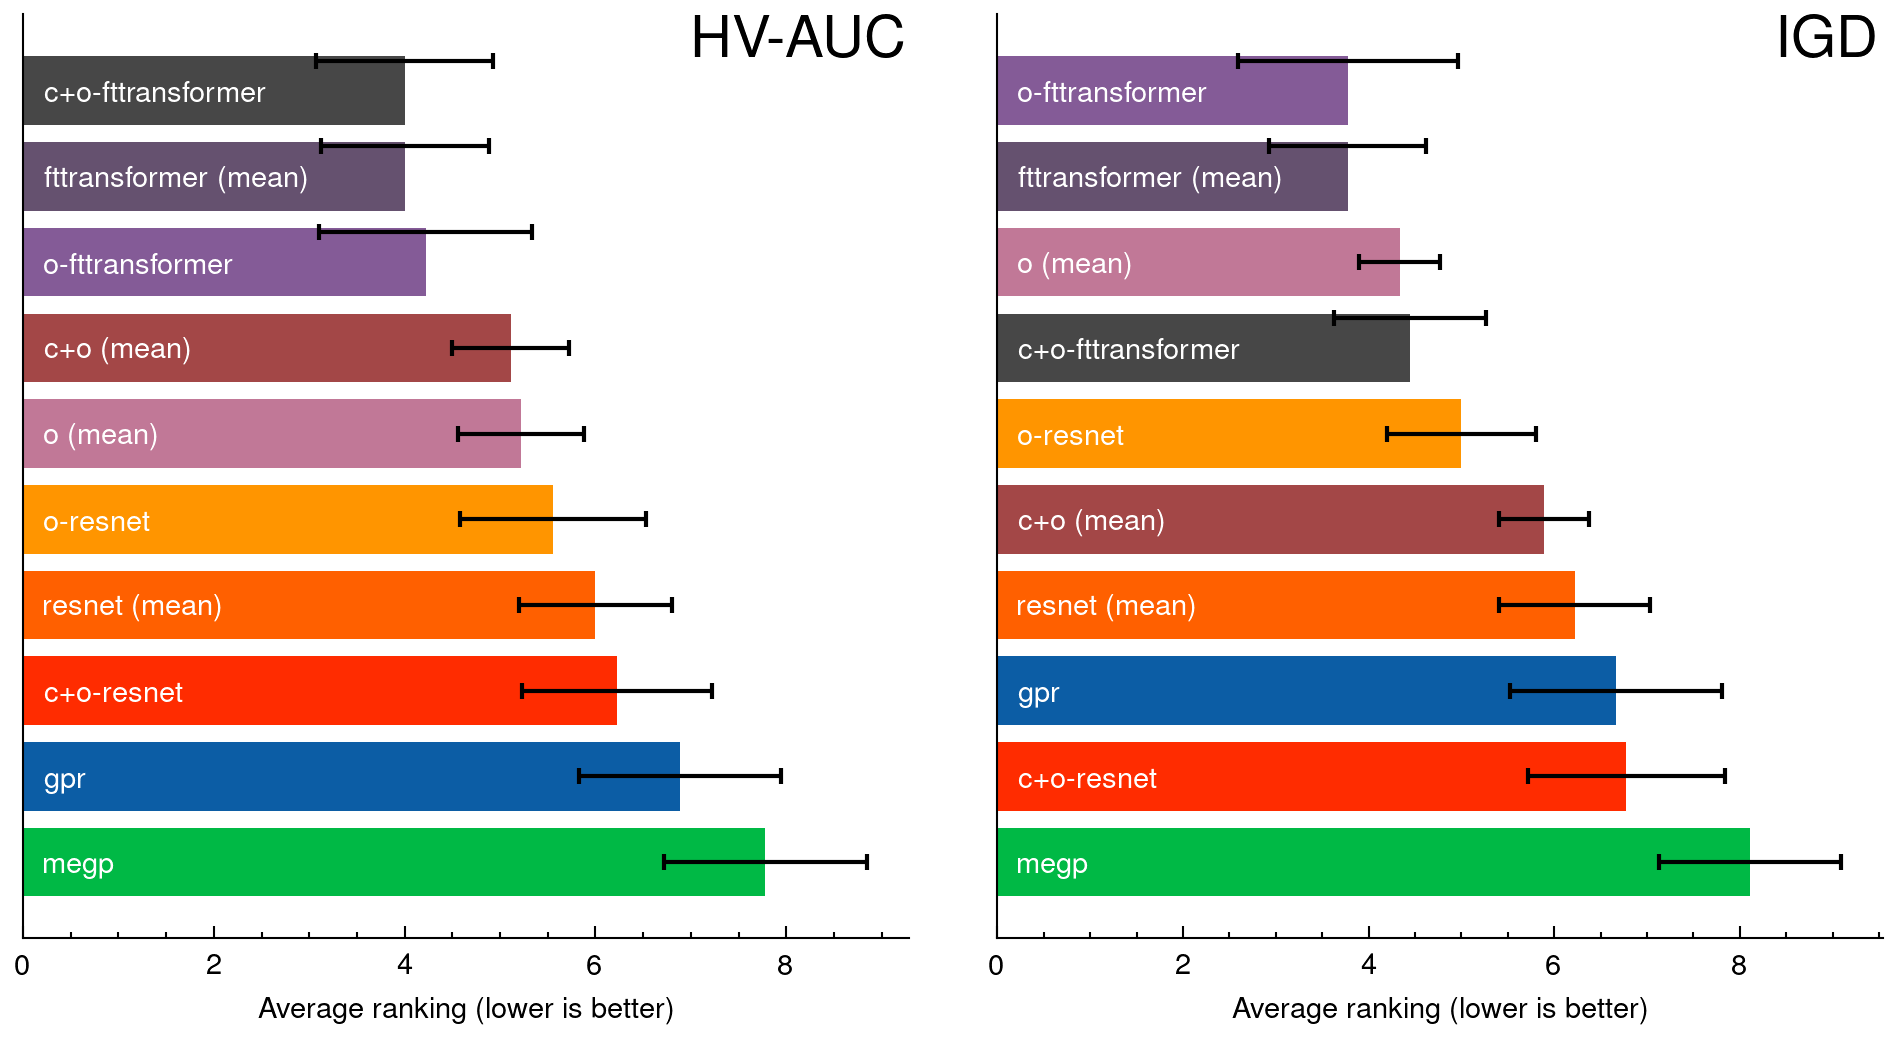

In [9]:
plt.rcParams["ytick.left"] = False
plt.rcParams["ytick.right"] = False
plt.rcParams["xtick.top"] = False

fig, axs = plt.subplots(1, 2, figsize=(8, 4))

auc_hvs = compute_auc_hvs(baseline_hvs)

# substract baseline
auc_hvs_norm = {}
for cell_type, methods in auc_hvs.items():
    baseline = methods["baseline"]
    auc_hvs_norm[cell_type] = {}

    for method, values in methods.items():
        if method != "baseline":
            auc_hvs_norm[cell_type][method] = [
                val - base_val for val, base_val in zip(values, baseline)
            ]

sections = {
    "gpr": ("gpr",),
    "megp": ("megp",),
    "o-resnet": ("o-resnet",),
    "c+o-resnet": ("c+o-resnet",),
    "o-fttransformer": ("o-fttransformer",),
    "c+o-fttransformer": ("c+o-fttransformer",),
    "resnet (mean)": ("o-resnet", "c+o-resnet"),
    "fttransformer (mean)": ("o-fttransformer", "c+o-fttransformer"),
    "c+o (mean)": ("c+o-resnet", "c+o-fttransformer"),
    "o (mean)": ("o-resnet", "o-fttransformer"),
}

for ax, (title, data) in zip(axs.flatten(), [("auc", auc_hvs_norm), ("igds", igds)]):
    ranks = {}
    for p, val in data.items():  # for all populations
        scores = {}
        for label, section in sections.items():
            x = []
            for s in section:
                x += val[s]
            scores[label] = np.mean(x)

        # rank within population (higher score gets lower rank where 1 is best)
        sorted_items = sorted(
            scores.items(), key=lambda x: x[1], reverse=title == "auc"
        )
        population_ranks = {
            label: rank + 1 for rank, (label, _) in enumerate(sorted_items)
        }

        if not ranks:
            ranks = {label: [] for label in scores.keys()}

        for label, rank in population_ranks.items():
            ranks[label].append(rank)

    ranks_err = {label: ufloat(np.mean(r), stats.sem(r)) for label, r in ranks.items()}

    num_populations = len(auc_hvs_norm)
    avg_ranks = {label: rank / num_populations for label, rank in ranks_err.items()}

    sorted_ranks = sorted(ranks_err.items(), key=lambda x: x[1])
    sorted_avg_ranks = sorted(avg_ranks.items(), key=lambda x: x[1])

    print(title)
    print(sorted_avg_ranks)

    ranking = [name for (name, v) in sorted_avg_ranks]
    y_pos = np.arange(len(ranking))
    score = [np.mean(ranks[k]) for k in ranking]
    error = [stats.sem(ranks[k]) for k in ranking]

    # move errorbars that overlap with text
    ax.errorbar(
        score,
        y_pos - np.array([0.35 if "ftt" in k else 0.0 for k in ranking]),
        xerr=error,
        fmt="none",
        capsize=2,
        ecolor="black",
    )
    ax.barh(
        y_pos,
        score,
        align="center",
        color=[
            {
                "fttransformer (mean)": "#65516F",
                "c+o (mean)": "#A34747",
                "o (mean)": "#C17897",
                "resnet (mean)": "#FF6000",
                **mcolors,
            }[k]
            for k in ranking
        ],
    )

    ax.set_yticks(
        y_pos, labels=[l.replace("fttransformer", "fttransformer") for l in ranking]
    )
    ax.tick_params(axis="y", pad=-5, top=True, bottom=True, left=False, right=False)
    [t.set_color("white") for t in ax.yaxis.get_ticklabels()]
    for tick in ax.yaxis.get_majorticklabels():
        tick.set_horizontalalignment("left")
    ax.invert_yaxis()
    ax.set_xlabel("Average ranking (lower is better)")
    ax.set_title(
        {"auc": "HV-AUC", "igds": "IGD"}[title],
        loc="right",
        y=1.0,
        pad=-10,
        fontsize=14,
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.subplots_adjust(wspace=0.1)

In [171]:
stash("figure3-ranking", fig)

auc
[('c+o-fttransformer', 0.3884297520661157+/-0.08931739561062016), ('fttransformer (mean)', 0.4380165289256199+/-0.0820640766102903), ('o-fttransformer', 0.4462809917355372+/-0.0953104346667008), ('o-resnet', 0.4628099173553719+/-0.07796678621534384), ('c+o (mean)', 0.47107438016528924+/-0.05457049262551794), ('o (mean)', 0.4958677685950413+/-0.05925106885598321), ('resnet (mean)', 0.5123966942148761+/-0.06401625365632094), ('c+o-resnet', 0.5537190082644629+/-0.07401194438756402), ('megp', 0.6033057851239669+/-0.10492939007010829), ('gpr', 0.628099173553719+/-0.07796678621534384)]
igds
[('o-fttransformer', 0.2975206611570248+/-0.09262099653634315), ('fttransformer (mean)', 0.35537190082644626+/-0.0653885634540578), ('o (mean)', 0.35537190082644626+/-0.041487274043012015), ('o-resnet', 0.47933884297520657+/-0.0638025093078307), ('c+o-fttransformer', 0.47933884297520657+/-0.07857761536532043), ('resnet (mean)', 0.5371900826446281+/-0.06304869792648149), ('c+o (mean)', 0.54545454545454

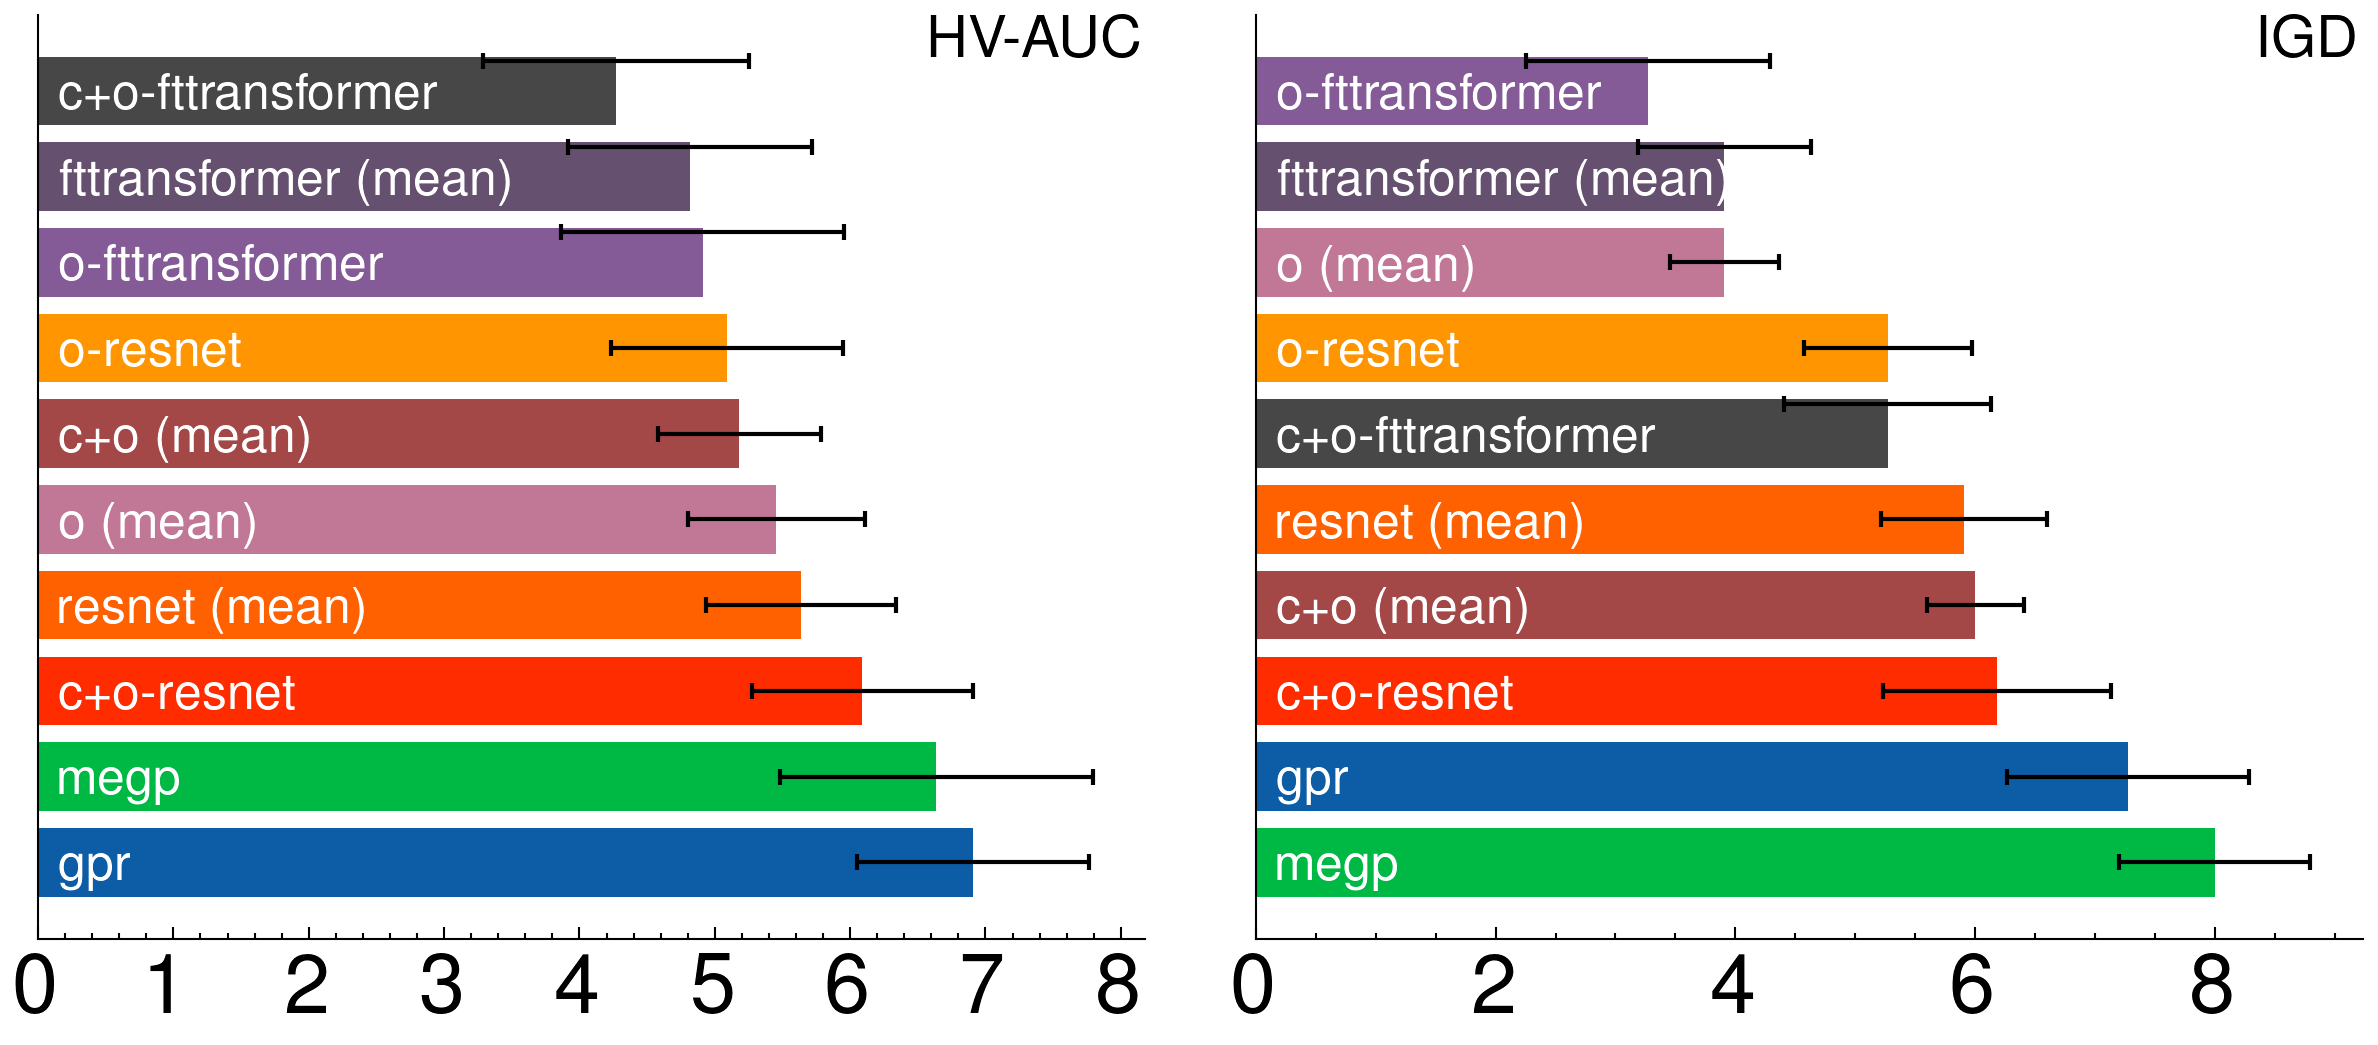

In [89]:


with rc_context():
    plt.rcParams["ytick.left"] = False
    plt.rcParams["ytick.right"] = False
    plt.rcParams["xtick.top"] = False

    fig, axs = plt.subplots(1, 2, figsize=(10, 4))

    auc_hvs = compute_auc_hvs(baseline_hvs)

    # substract baseline
    auc_hvs_norm = {}
    for cell_type, methods in auc_hvs.items():
        baseline = methods["baseline"]
        auc_hvs_norm[cell_type] = {}

        for method, values in methods.items():
            if method != "baseline":
                auc_hvs_norm[cell_type][method] = [
                    val - base_val for val, base_val in zip(values, baseline)
                ]

    sections = {
        "gpr": ("gpr",),
        "megp": ("megp",),
        "o-resnet": ("o-resnet",),
        "c+o-resnet": ("c+o-resnet",),
        "o-fttransformer": ("o-fttransformer",),
        "c+o-fttransformer": ("c+o-fttransformer",),
        "resnet (mean)": ("o-resnet", "c+o-resnet"),
        "fttransformer (mean)": ("o-fttransformer", "c+o-fttransformer"),
        "c+o (mean)": ("c+o-resnet", "c+o-fttransformer"),
        "o (mean)": ("o-resnet", "o-fttransformer"),
    }

    for ax, (title, data) in zip(axs.flatten(), [("auc", auc_hvs_norm), ("igds", igds)]):
        ranks = {}
        for p, val in data.items():  # for all populations
            scores = {}
            for label, section in sections.items():
                x = []
                for s in section:
                    x += val[s]
                scores[label] = np.mean(x)

            # rank within population (higher score gets lower rank where 1 is best)
            sorted_items = sorted(
                scores.items(), key=lambda x: x[1], reverse=title == "auc"
            )
            population_ranks = {
                label: rank + 1 for rank, (label, _) in enumerate(sorted_items)
            }

            if not ranks:
                ranks = {label: [] for label in scores.keys()}

            for label, rank in population_ranks.items():
                ranks[label].append(rank)

        ranks_err = {label: ufloat(np.mean(r), stats.sem(r)) for label, r in ranks.items()}

        num_populations = len(auc_hvs_norm)
        avg_ranks = {label: rank / num_populations for label, rank in ranks_err.items()}

        sorted_ranks = sorted(ranks_err.items(), key=lambda x: x[1])
        sorted_avg_ranks = sorted(avg_ranks.items(), key=lambda x: x[1])

        print(title)
        print(sorted_avg_ranks)

        ranking = [name for (name, v) in sorted_avg_ranks]
        y_pos = np.arange(len(ranking))
        score = [np.mean(ranks[k]) for k in ranking]
        error = [stats.sem(ranks[k]) for k in ranking]

        # move errorbars that overlap with text
        ax.errorbar(
            score,
            y_pos - np.array([0.35 if "ftt" in k else 0.0 for k in ranking]),
            xerr=error,
            fmt="none",
            capsize=2,
            ecolor="black",
        )
        ax.barh(
            y_pos,
            score,
            align="center",
            color=[
                {
                    "fttransformer (mean)": "#65516F",
                    "c+o (mean)": "#A34747",
                    "o (mean)": "#C17897",
                    "resnet (mean)": "#FF6000",
                    **mcolors,
                }[k]
                for k in ranking
            ],
        )

        ax.set_yticks(
            y_pos, labels=[l.replace("fttransformer", "fttransformer") for l in ranking], size=12
        )
        ax.tick_params(axis="y", pad=-5, top=True, bottom=True, left=False, right=False)
        [t.set_color("white") for t in ax.yaxis.get_ticklabels()]
        for tick in ax.yaxis.get_majorticklabels():
            tick.set_horizontalalignment("left")
        ax.invert_yaxis()
        #ax.set_xlabel("Average ranking (lower is better)")
        ax.set_title(
            {"auc": "HV-AUC", "igds": "IGD"}[title],
            loc="right",
            y=1.0,
            pad=-10,
            fontsize=14,
        )
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.subplots_adjust(wspace=0.1)

In [90]:
stash("figure3/ranking-large", fig)

## Sensitivity

In [2]:
_ca1_sa = get("interface._ca1_sa")

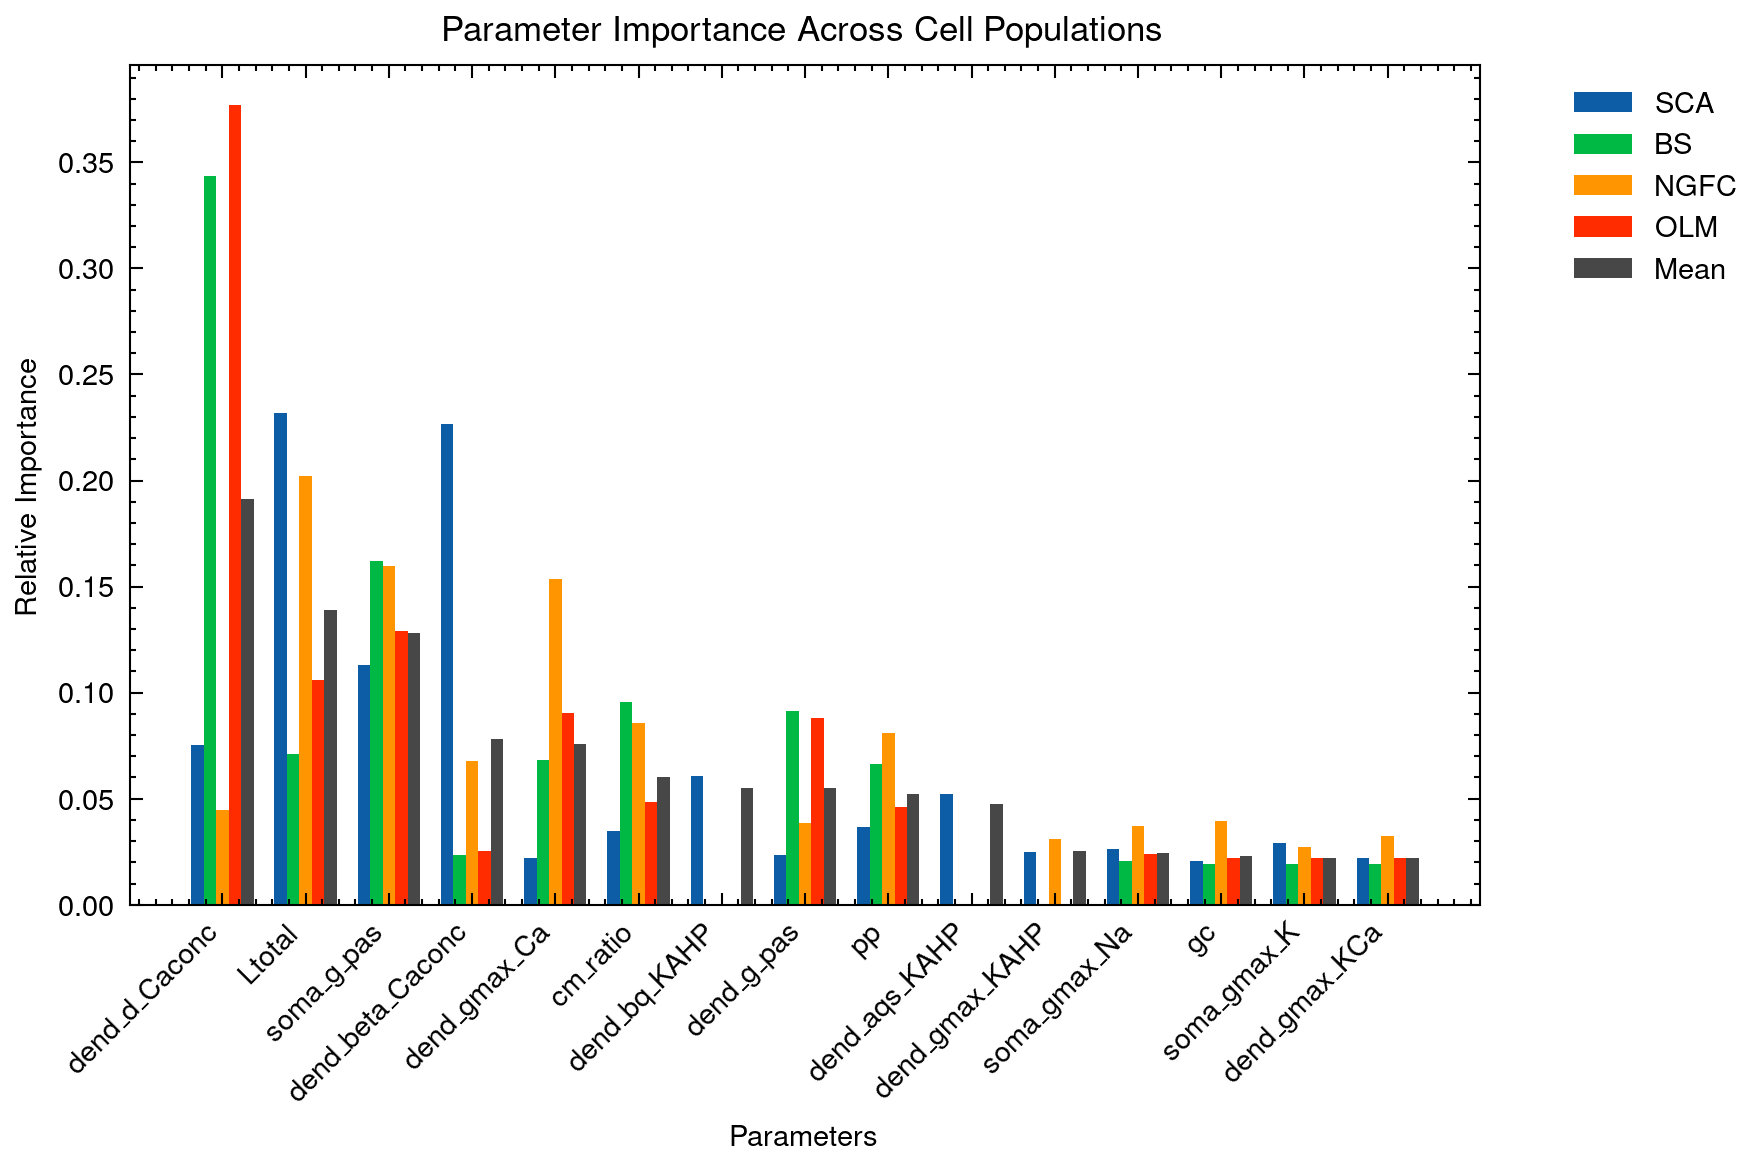

In [44]:
for p in _ca1_sa.populations():
    experiments = _ca1_sa.components.filter(
        lambda x: p in x.label()
        and not x.load_attribute("preflight", False)
        and x.cached()
    )
    
    dfs = {}
    for experiment in experiments:
        model_name = str(
            experiment.config.dopt_params.surrogate_custom_training_kwargs.get(
                "sensitivity", "-"
            )
        )
        model_name += str(
            experiment.config.dopt_params.get("sensitivity_method_name", "-")
        )
        model_name = model_name.replace("-", "").replace("True", "sgrad")
        
        if model_name != 'sgrad':
            continue
        
        q = experiment.load_h5_optimizer_data()['params'][['di_crossover']]
        q = pd.DataFrame([row[0] for row in q.values], columns=experiment.parameter_names).mean()
        
        if model_name not in dfs:
            dfs[model_name] = []
            
        dfs[model_name].append(q)
        
    
    # Store importance data for all populations
    if p == 'SCA':  # Initialize on first population
        importance_data = {}
        
    # Process and store importance data for this population
    for m in dfs:
        df = pd.concat(dfs[m], axis=1)
        df_reduced = df.mean(axis=1)
        normalized = df_reduced / df_reduced.sum()
        
        # Sort parameters by importance (descending)
        ranked_params = normalized.sort_values(ascending=False)
        
        # Store data for later plotting
        importance_data[p] = ranked_params


plt.figure(figsize=(6, 4))

# Calculate mean importance across all populations and sort parameters
mean_importance = pd.DataFrame(importance_data).mean(axis=1)
normalized_mean = mean_importance / mean_importance.sum()

# Sort parameters by mean importance
sorted_params = normalized_mean.sort_values(ascending=False).index.tolist()

# Prepare data for plotting
x = np.arange(len(sorted_params))
width = 0.15  # Reduced width to add space between parameter groups

# Plot bars for each population
for i, (pop, data) in enumerate(importance_data.items()):
    values = [data.get(param, 0) for param in sorted_params]
    plt.bar(x + i*width, values, width, label=pop, color=colors[['blue', 'green', 'yellow', 'red'][i]])

# Add mean bars
values = [normalized_mean[param] for param in sorted_params]
plt.bar(x + len(importance_data)*width, values, width, label='Mean', color=colors['black'])

plt.xlabel('Parameters')
plt.ylabel('Relative Importance')
plt.title('Parameter Importance Across Cell Populations')
plt.xticks(x + width * (len(importance_data))/2, sorted_params, rotation=45, ha='right')

# Update legend and layout
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

In [174]:
sa_hvs = {}

for p in _ca1_sa.populations():
    experiments = _ca1_sa.components.filter(
        lambda x: p in x.label()
        and not x.load_attribute("preflight", False)
        and x.cached()
    )
    nadir = nadirs[p]

    for experiment in experiments:
        model_name = str(
            experiment.config.dopt_params.surrogate_custom_training_kwargs.get(
                "sensitivity", "-"
            )
        )
        model_name += str(
            experiment.config.dopt_params.get("sensitivity_method_name", "-")
        )
        model_name = model_name.replace("-", "").replace("True", "sgrad")

        sa_hvs.setdefault(p, {})

        epoch_ranges = experiment.epoch_ranges(from_zero=True)

        sa_hvs[p].setdefault(model_name, {})
        for epoch, region in enumerate(epoch_ranges):
            sa_hvs[p][model_name].setdefault(epoch, [])
            hv = experiment.norm_hv_region(nadir, region)
            sa_hvs[p][model_name][epoch].append(hv)


sa_hvs_reduced = {}
for p, sahvs in sa_hvs.items():
    sa_hvs_reduced.setdefault(p, {})
    for model_name, vals in sahvs.items():
        sa_hvs_reduced[p].setdefault(model_name, {})
        sa_hvs_reduced[p][model_name] = vals[9]

In [169]:
sa_igds = {}

for p in _ca1_sa.populations():
    experiments = _ca1_sa.components.filter(
        lambda x: p in x.label()
        and not x.load_attribute("preflight", False)
        and x.cached()
    )

    baselines = _ca1_sopt_baseline.components.filter(
        lambda x: p in x.label()
        and not x.load_attribute("preflight", False)
        and x.mO == "-"
    )

    for experiment in experiments:
        model_name = str(
            experiment.config.dopt_params.surrogate_custom_training_kwargs.get(
                "sensitivity", "-"
            )
        )
        model_name += str(
            experiment.config.dopt_params.get("sensitivity_method_name", "-")
        )
        model_name = model_name.replace("-", "").replace("True", "sgrad")
        sa_igds.setdefault(p, {})
        sa_igds[p][model_name] = [float(experiment.igd(b)) for b in baselines]

    # baseline
    # q = igds[p]['c+o-fttransformer']
    # sa_igds[p]['none'] = ufloat(np.mean(q), np.std(q))

In [176]:
stash("figure3-sa_hvs", sa_hvs)
stash("figure3-sa_igds", sa_igds)
stash("figure3-sa_hvs_reduced", sa_hvs_reduced)

In [63]:
sa_hvs = restore("figure3-sa_hvs")
sa_igds = restore("figure3-sa_igds")
sa_hvs_reduced = restore("figure3-sa_hvs_reduced")

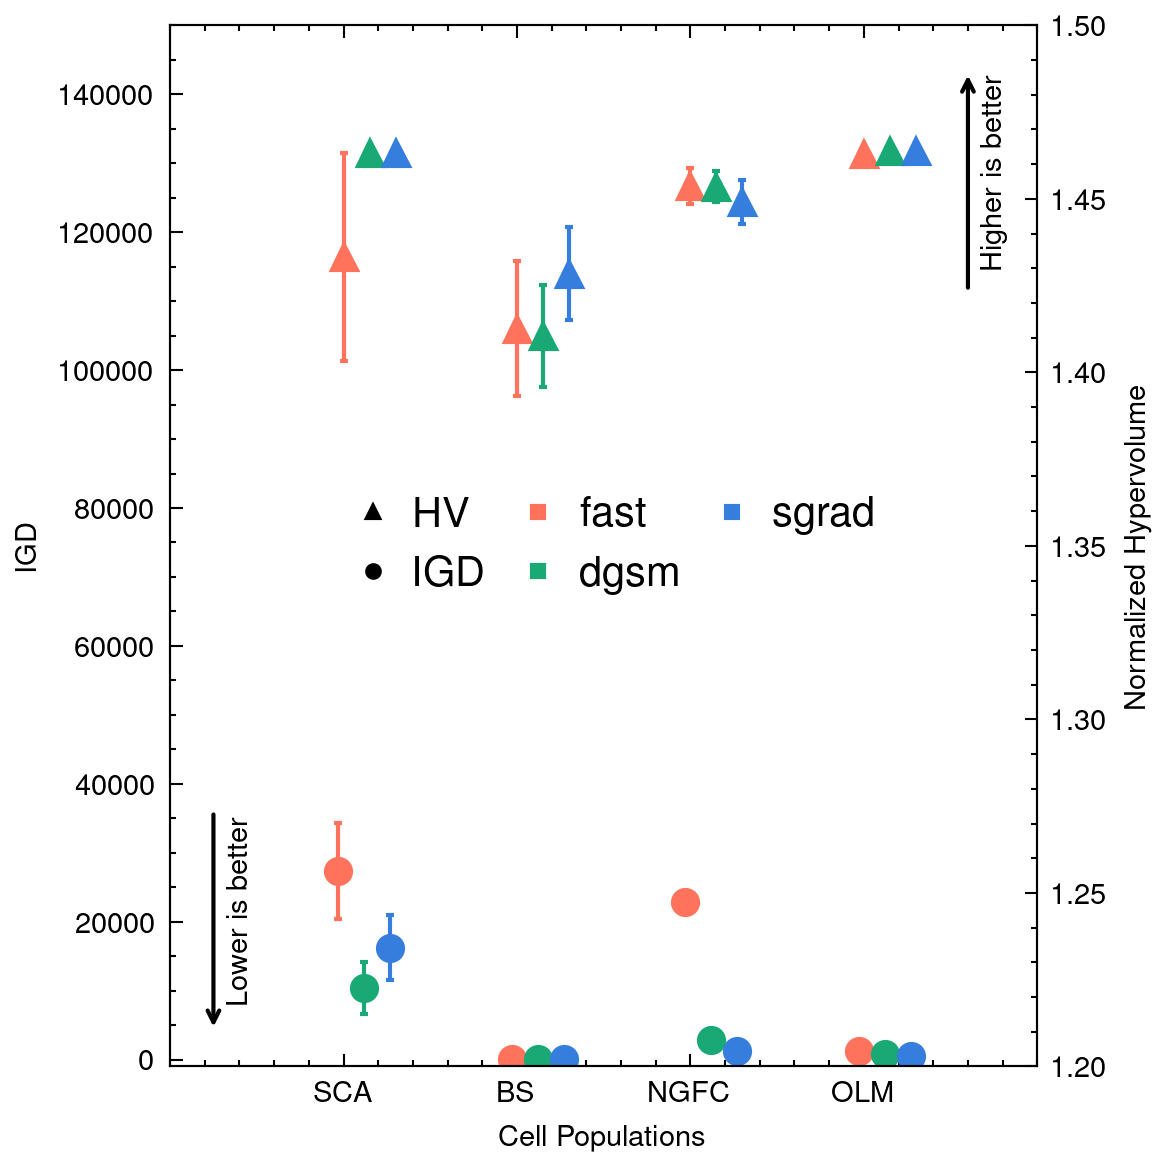

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.legend_handler import HandlerTuple

populations = ["SCA", "BS", "NGFC", "OLM"]

fig, ax1 = plt.subplots(figsize=(4, 4))

ops = [
    "fast",
    "dgsm",
    "sgrad",  #'cross_check'
]

ccc = {"fast": "#FF725C", "dgsm": "#19A974", "sgrad": "#357EDD"}

for i, model in enumerate(ops):
    x = np.arange(len(populations))  # - 0.15  # offset left

    y = [np.mean(sa_igds[p][model]) for p in populations]
    yerr = [stats.sem(sa_igds[p][model]) for p in populations]
    ax1.errorbar(
        x + i * 0.15 - 0.03,
        y,
        yerr=yerr,
        fmt="o",
        color=ccc[model],
        capsize=1,
        markersize=6,
        label=f"{model} IGD",
    )

ax1.set_xlabel("Cell Populations")
ax1.set_ylabel("IGD")
ax1.tick_params(axis="y")
ax1.set_ylim([-1e3, 1.5*1e5+1])

ax1.set_xlim([-1, 4])

ax2 = ax1.twinx()


for i, model in enumerate(ops):
    x = np.arange(len(populations))  # + 0.15  # offset right
    y = [np.mean(sa_hvs_reduced[p][model]) for p in populations]
    yerr = [stats.sem(sa_hvs_reduced[p][model]) for p in populations]
    ax2.errorbar(
        x + i * 0.15,
        y,
        yerr=yerr,
        fmt="^",
        color=ccc[model],
        capsize=1,
        markersize=6,
        label=f"{model} HV",
    )

ax2.set_ylabel("Normalized Hypervolume")
ax2.tick_params(axis="y")
ax2.set_ylim([1.2, 1.5])


plt.xticks(np.arange(len(populations)), populations)

igd_lines = [
    plt.Line2D([], [], marker="o", color="black", linestyle="None", label="IGD")
]
hv_lines = [plt.Line2D([], [], marker="^", color="black", linestyle="None", label="HV")]

method_lines = [
    plt.Line2D([], [], marker="s", color=ccc[method], linestyle="None", label=method)
    for i, method in enumerate(ops)
]


ax1.legend(
    hv_lines + igd_lines + method_lines,
    ["HV","IGD", "fast", "dgsm", "sgrad",  ],
    handler_map={tuple: HandlerTuple(ndivide=None)},
    loc="center",
    fontsize=10,
    ncols=3,
    columnspacing=0.2,  # reduce spacing between columns
    handletextpad=0.   # reduce spacing between marker and text
)

# lower
lx = 0.05
ly = 0.25
ax1.annotate(
    "",
    xy=(lx, ly),
    xytext=(lx, ly - 0.22),
    xycoords="axes fraction",
    arrowprops=dict(arrowstyle="<-", color="black"),
    annotation_clip=False,
)
ax1.text(
    lx + 0.03,
    ly - 0.1,
    "Lower is better",
    rotation=90,
    va="center",
    ha="center",
    transform=ax1.transAxes,
)


# upper
lx = 0.92
ly = 0.96
ax1.annotate(
    "",
    xy=(lx, ly),
    xytext=(lx, ly - 0.22),
    xycoords="axes fraction",
    arrowprops=dict(arrowstyle="->", color="black"),
    annotation_clip=False,
)
ax1.text(
    lx + 0.03,
    ly - 0.1,
    "Higher is better",
    rotation=90,
    va="center",
    ha="center",
    transform=ax1.transAxes,
)


plt.tight_layout()

In [65]:
stash("figure3-sensitivity-analysis", fig)

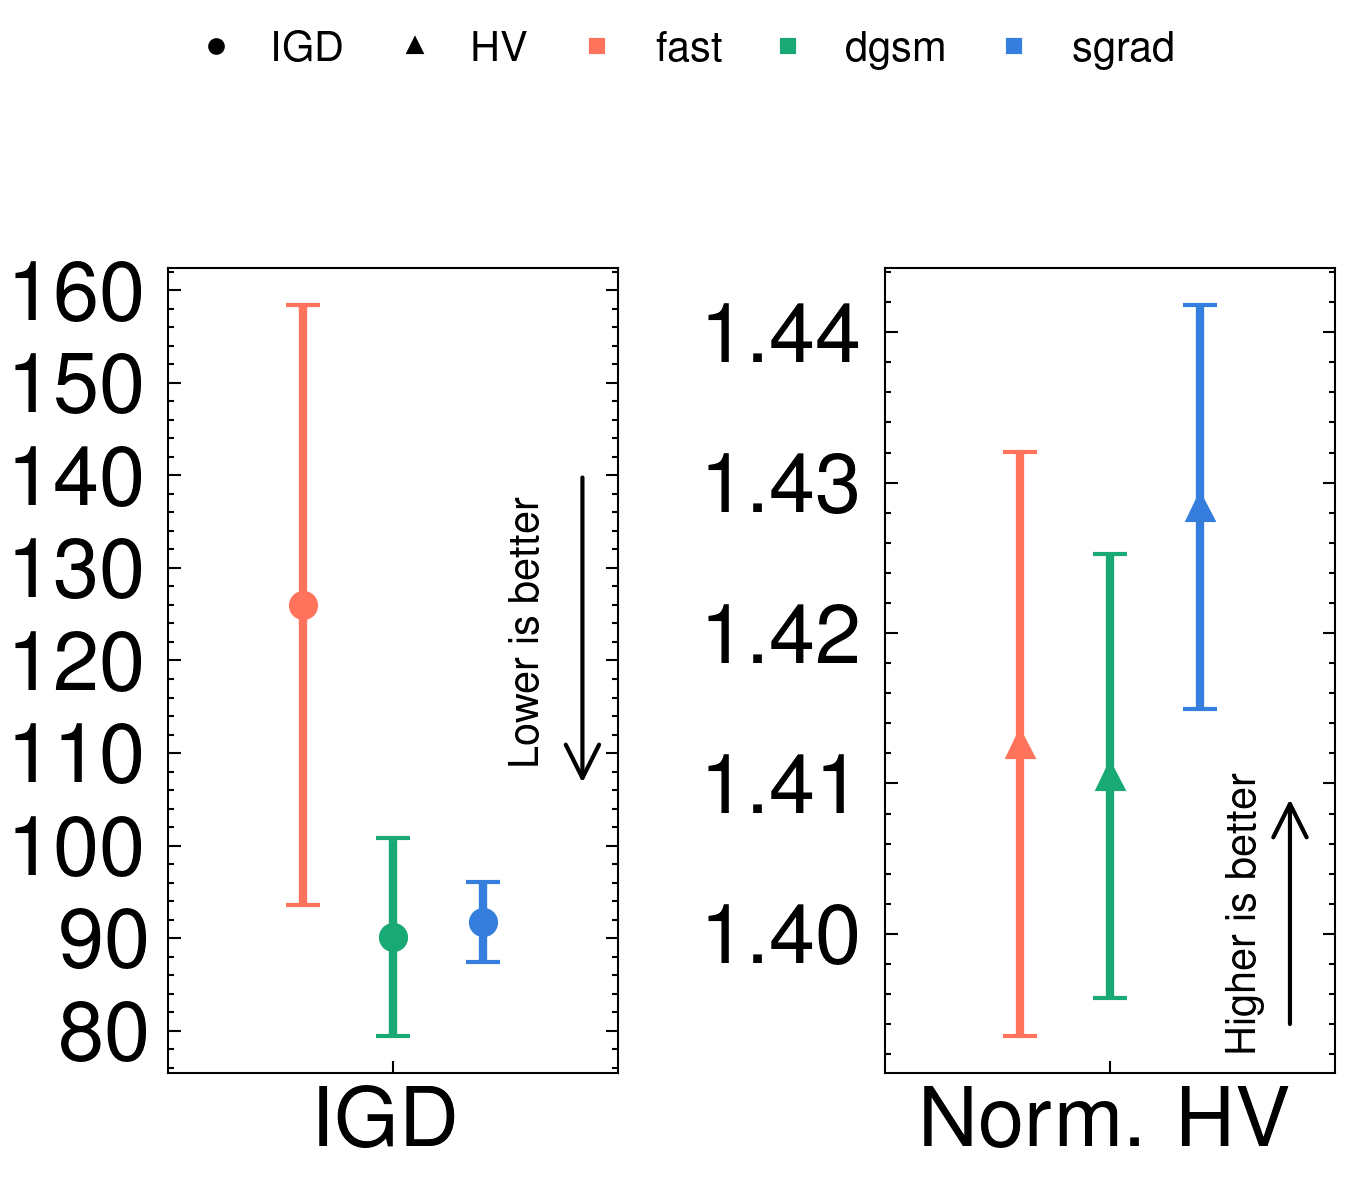

In [85]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.legend_handler import HandlerTuple

with rc_context():
    populations = ["BS"]
    x_positions = np.arange(len(populations))

    fig, (ax_igd, ax_hv) = plt.subplots(1, 2, figsize=(5, 4))
    marker_offset = 0.2

    for i, model in enumerate(ops):
        offset = (i - (len(ops) - 1) / 2) * marker_offset
        igd_values = [np.mean(sa_igds[p][model]) for p in populations]
        igd_err = [stats.sem(sa_igds[p][model]) for p in populations]
        ax_igd.errorbar(
            x_positions + offset,
            igd_values,
            yerr=igd_err,
            fmt="o",
            color=ccc[model],
            capsize=4,
            markersize=6,
            label=f"{model} IGD",
            linewidth=2
        )

    #ax_igd.set_ylabel("IGD")
    #ax_igd.set_ylim([-1e3, 1.5 * 1e5 + 1])
    ax_igd.tick_params(axis="y")
    ax_igd.annotate(
        "",
        xy=(0.92, 0.35),
        xytext=(0.92, 0.75),
        xycoords="axes fraction",
        arrowprops=dict(arrowstyle="->", color="black"),
        annotation_clip=False,
    )
    ax_igd.text(
        0.8,
        0.55,
        "Lower is better",
        rotation=90,
        va="center",
        ha="center",
        transform=ax_igd.transAxes,
        size=10,
    )

    for i, model in enumerate(ops):
        offset = (i - (len(ops) - 1) / 2) * marker_offset
        hv_values = [np.mean(sa_hvs_reduced[p][model]) for p in populations]
        hv_err = [stats.sem(sa_hvs_reduced[p][model]) for p in populations]
        ax_hv.errorbar(
            x_positions + offset,
            hv_values,
            yerr=hv_err,
            fmt="^",
            color=ccc[model],
            capsize=4,
            markersize=6,
            label=f"{model} HV",
            linewidth=2
        )

    #ax_hv.set_ylabel("Normalized Hypervolume")
    #ax_hv.set_ylim([1.2, 1.5])
    ax_hv.tick_params(axis="y")
    ax_hv.annotate(
        "",
        xy=(0.9, 0.35),
        xytext=(0.9, 0.05),
        xycoords="axes fraction",
        arrowprops=dict(arrowstyle="->", color="black"),
        annotation_clip=False,
    )
    ax_hv.text(
        0.8,
        0.2,
        "Higher is better",
        rotation=90,
        va="center",
        ha="center",
        transform=ax_hv.transAxes,
        size=10,
    )

    i = 0
    for axis in (ax_igd, ax_hv):
        axis.set_xlim([-0.5, len(populations) - 0.5])
        axis.set_xticks(x_positions)
        axis.set_xticklabels(["IGD" if i == 0 else "Norm. HV"])
        i += 1

    igd_lines = [
        plt.Line2D([], [], marker="o", color="black", linestyle="None", label="IGD")
    ]
    hv_lines = [
        plt.Line2D([], [], marker="^", color="black", linestyle="None", label="HV")
    ]
    method_lines = [
        plt.Line2D([], [], marker="s", color=ccc[method], linestyle="None", label=method)
        for method in ops
    ]

    fig.legend(
        igd_lines + hv_lines + method_lines,
        ["IGD", "HV", *ops],
        loc="upper center",
        bbox_to_anchor=(0.5, 1.05),
        ncol=len(ops) + 2,
        columnspacing=0.6,
        handletextpad=0.4,
        fontsize=10,
    )

    fig.tight_layout(rect=(0, 0, 1, 0.9))


In [86]:
stash("figure3/sensitivity-analysis-bs", fig)

### Hypervolume data

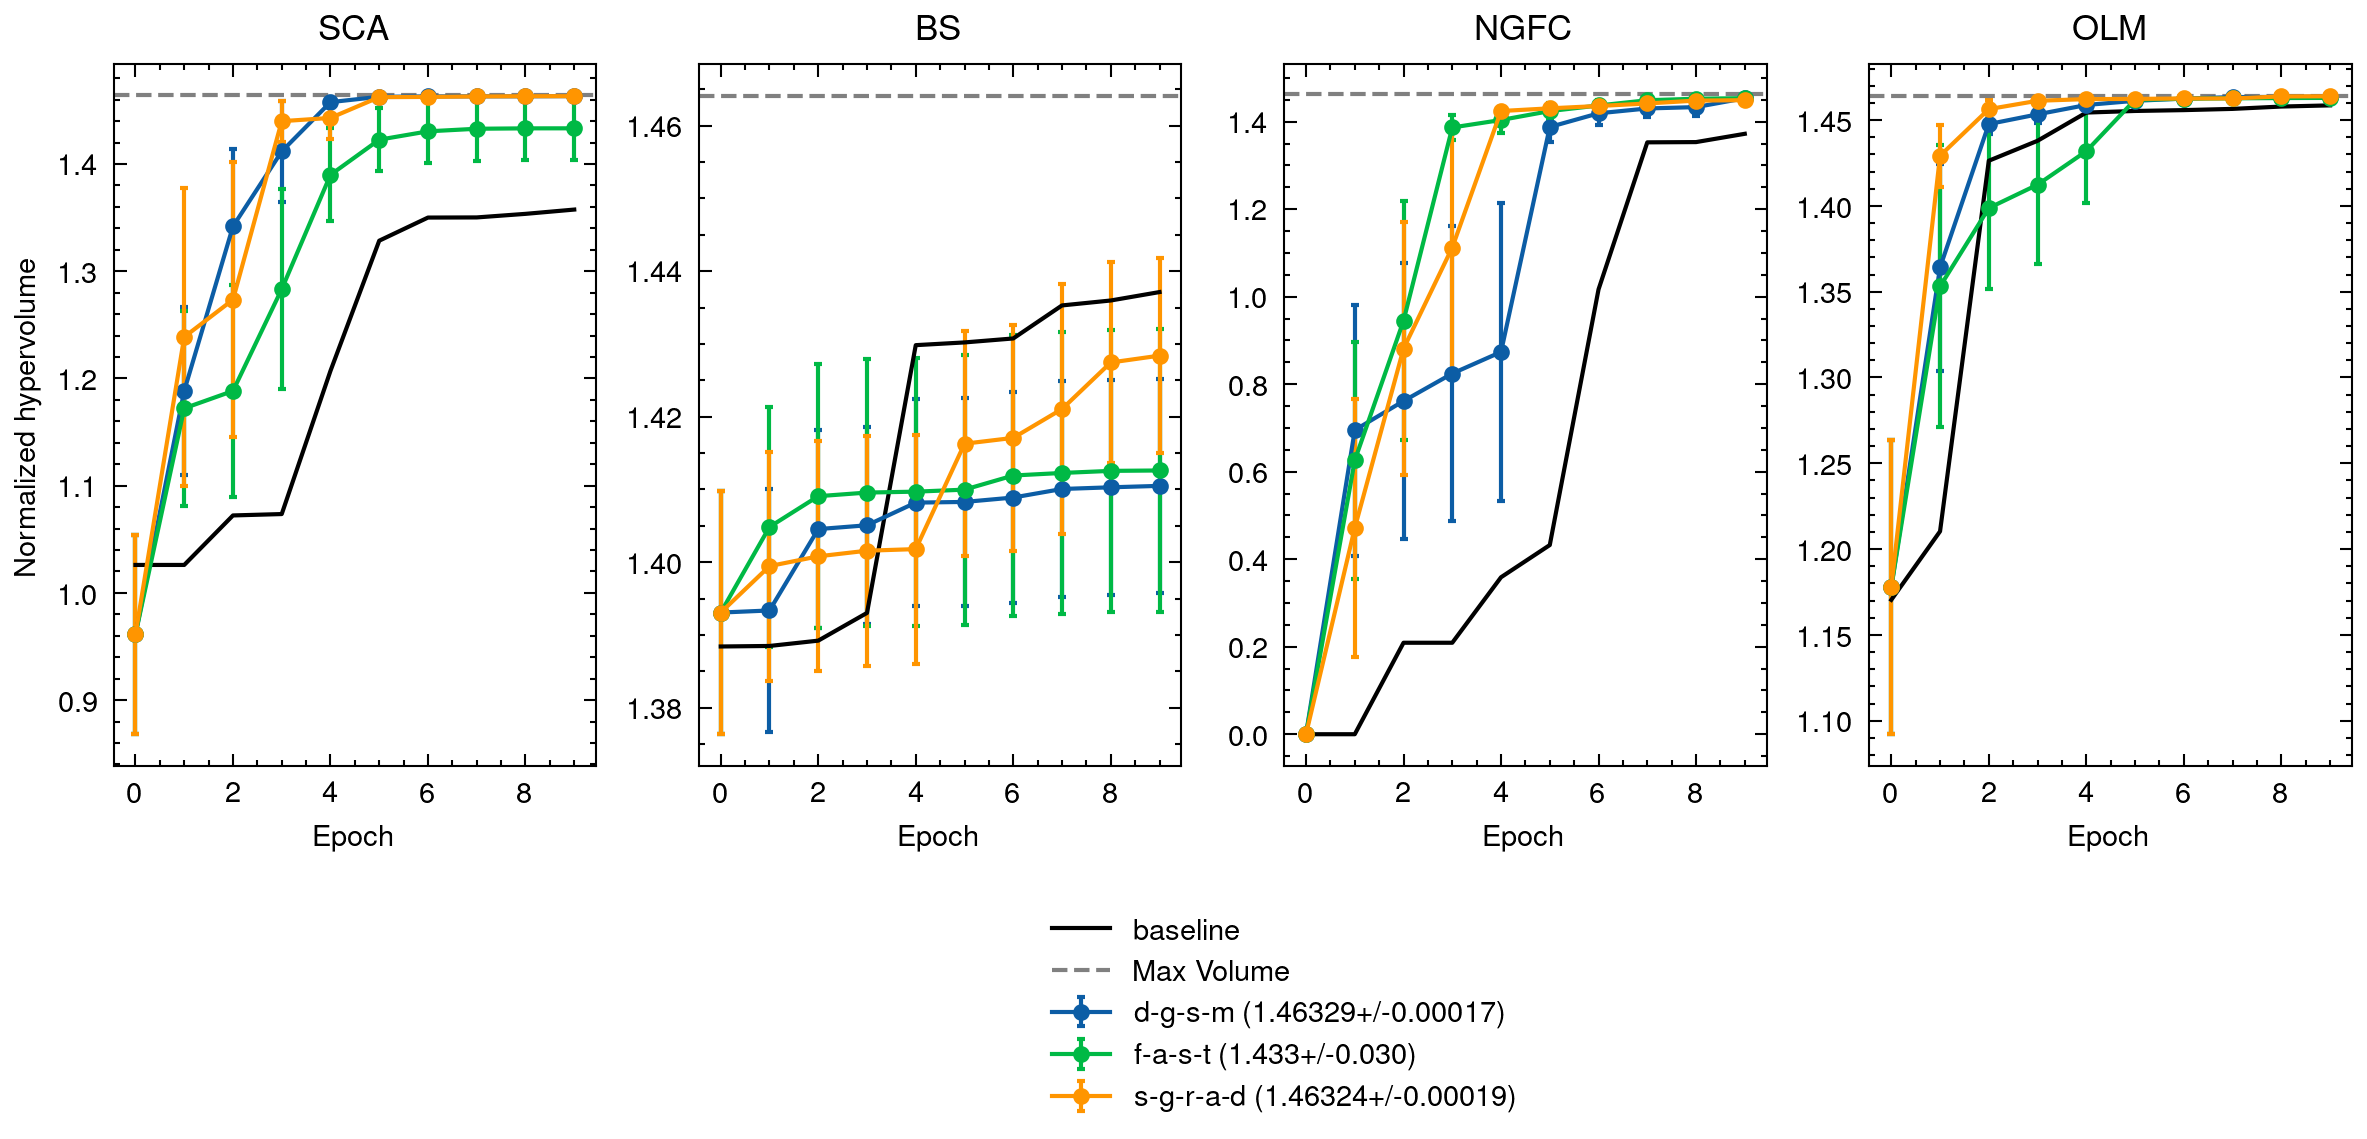

In [167]:
from uncertainties import ufloat
from scipy import stats


fig, axs = plt.subplots(1, len(sa_hvs), figsize=(8, 3), sharey=False)

# axs = np.array([axs])

for ax, (p, models) in zip(axs.flatten(), sa_hvs.items()):
    for model_name, epoch_hvs in models.items():
        x = []
        y = []
        y_err = []
        for epoch, hvs in epoch_hvs.items():
            x.append(int(epoch))
            y.append(np.mean(hvs))
            y_err.append(stats.sem(hvs))

        if model_name == "cross_check":
            continue

        ax.errorbar(
            x,
            y,
            yerr=y_err,
            label="-".join(model_name) + f" ({ufloat(y[-1], y_err[-1])})",
            fmt="-o",
            capsize=1,
        )

        # print(p, model_name, ufloat(y[-1], y_err[-1]))

    y = []
    for epoch, hvs in baseline_hvs[p]["baseline"].items():
        y.append(np.mean(hvs))

    # print(p, 'baseline', y[:10][-1])

    ax.plot(x, y[:10], label="baseline", color="black")

    y = []
    for epoch, hvs in baseline_hvs[p]["c+o-fttransformer"].items():
        y.append(np.mean(hvs))

    # print(p, 'n/sa', y[:10][-1])

    # ax.plot(x,y[:10], label='c+o-fttransformer', color='yellow')

    ax.set_xlabel("Epoch")
    ax.axhline(y=1.1**4, color="grey", linestyle="--", label="Max Volume")
    # ax.set_ylim(0, 1.1**4 * 1.05)
    ax.set_title(p)


axs[0].set_ylabel("Normalized hypervolume")

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,  # ncol=len(labels),
    bbox_to_anchor=(0.65, -0.01),
)
plt.tight_layout()
plt.show()

# Gradient exploration

In [3]:
_ca1_bs = get("interface._ca1_bs")

bs_hvs = {}

experiments = _ca1_bs.components.filter(lambda x: x.cached())
nadir = nadirs["BS"]
for experiment in experiments:
    model_name = str(experiment.dynamic_sampling_kwargs.feasibility_targets)

    epoch_ranges = experiment.epoch_ranges(from_zero=True)

    bs_hvs.setdefault(model_name, {})
    for epoch, region in enumerate(epoch_ranges):
        bs_hvs[model_name].setdefault(epoch, [])
        hv = experiment.norm_hv_region(nadir, region)
        bs_hvs[model_name][epoch].append(hv)

numprocs=1


In [11]:
stash("figure3-bs_hvs", bs_hvs)

In [30]:
bs_hvs = restore("figure3-bs_hvs")

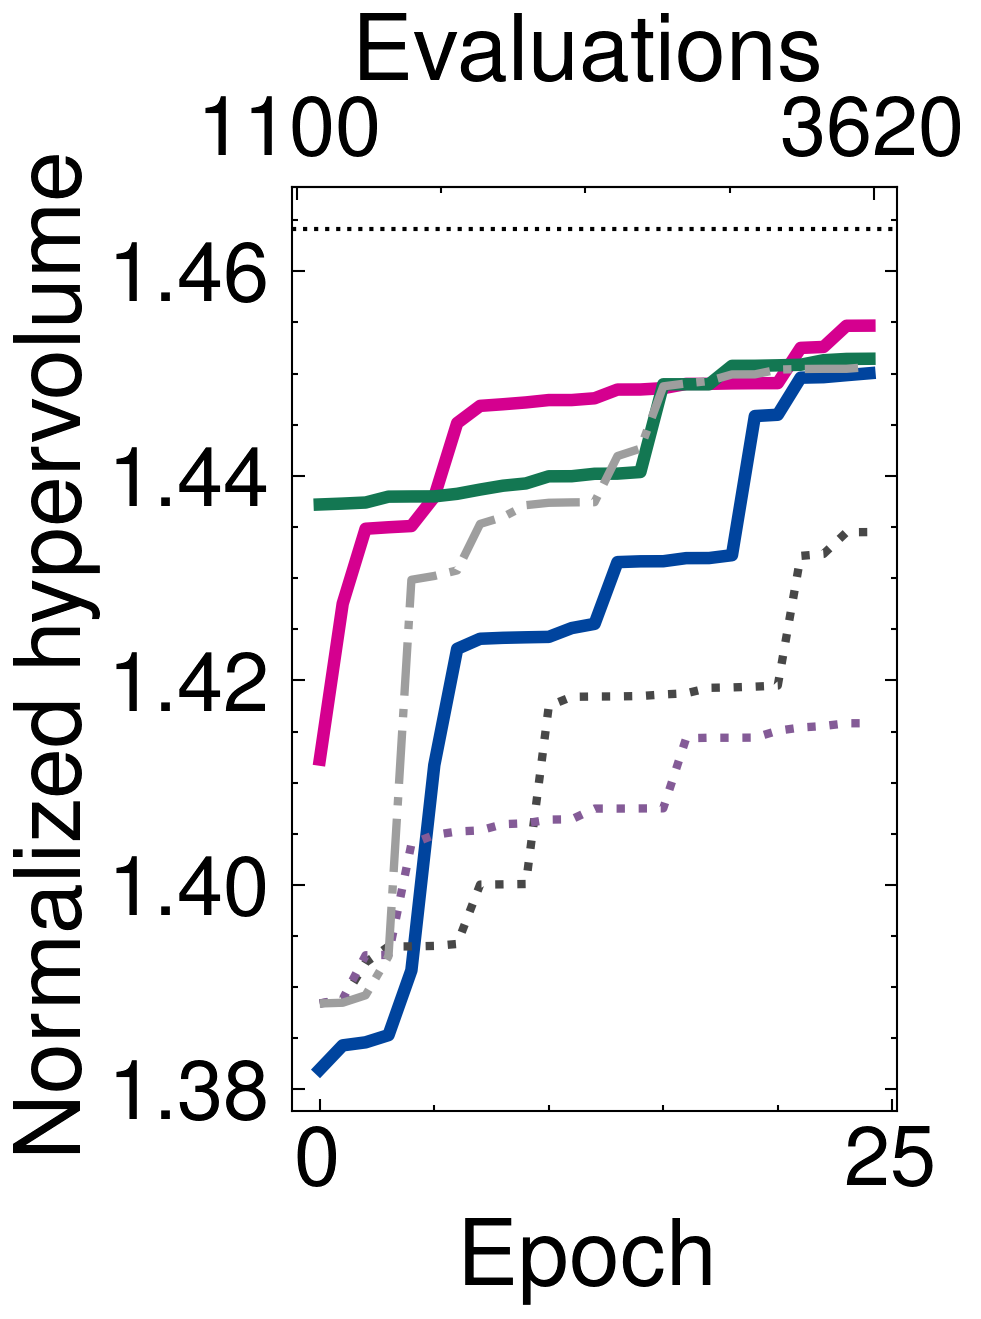

In [92]:
with rc_context():

    fig, ax = plt.subplots(1, 1, figsize=(2.6, 4))

    ax.axhline(y=1.1**4, color="black", linestyle=":", label="Max Volume")

    for model_name, epoch_hvs in bs_hvs.items():
        if "distance" in model_name:
            continue
        x = []
        y = []
        y_err = []
        for epoch, hvs in epoch_hvs.items():
            x.append(int(epoch))
            y.append(np.mean(hvs))
            y_err.append(stats.sem(hvs))

        #ax.errorbar(
        ax.plot(
            x,
            y,
            #yerr=y_err,
            label={
                "objective constraint": "$\\nabla$(c+o)",
                "objective": "$\\nabla$(o)",
                "constraint": "$\\nabla$(c)",
                # "objective distance": 'od',
                #  "distance": 'd',
                #  "objective constraint distance": 'ocd',
            }[model_name]
            + f" ({ufloat(y[-1], y_err[-1])})",
            #fmt="-o",
            color={
                "objective constraint": "#D5008F",
                "objective": "#137752",
                "constraint": "#00449E",
                # "objective distance": 'red',
                # "distance": 'blue',
                # "objective constraint distance": 'yellow',
            }[model_name],
            markersize=1,
            #capsize=1,
            #elinewidth=0.5,
            #capthick=0.5,
            linewidth=3
        )


    y = []
    for epoch, hvs in baseline_hvs["BS"]["c+o-fttransformer"].items():
        y.append(np.mean(hvs))

    ax.plot(
        x,
        y,
        label="c+o" + f" ({ufloat(y[-1], y_err[-1])})",
        color=mcolors["c+o-fttransformer"],
        linestyle="dotted",
        linewidth=2
    )

    y = []
    for epoch, hvs in baseline_hvs["BS"]["o-fttransformer"].items():
        y.append(np.mean(hvs))

    ax.plot(
        x,
        y,
        label="o" + f" ({ufloat(y[-1], y_err[-1])})",
        color=mcolors["o-fttransformer"],
        linestyle="dotted",
        linewidth=2
    )

    y = []
    for epoch, hvs in baseline_hvs["BS"]["baseline"].items():
        y.append(np.mean(hvs))

    ax.plot(
        x,
        y,
        label="baseline" + f" ({ufloat(y[-1], y_err[-1])})",
        color=colors["grey"],
        linestyle="dashdot",
        linewidth=2
    )

    ax.set_xlabel("Epoch")
    # ax.set_xlim([-0.5,25])
    ax.set_xticks([0, 25])

    #ax.set_ylim([1.35, 1.1**4+0.01])

    # ax.legend(loc='best')
    ax.tick_params(top=False)

    secax = ax.secondary_xaxis(
        "top",
        functions=(
            lambda x, ins=initial_samples["BS"]: x * 100 + ins,
            lambda x, ins=initial_samples["BS"]: (x + ins) / 100,
        ),
    )
    secax.set_xlabel("Evaluations")
    min_evals = initial_samples[p]
    max_evals = int(ax.get_xlim()[1] * 100 + initial_samples[p])
    secax.set_xlim(min_evals, max_evals)
    secax.set_xticks([min_evals, max_evals])

    ax.set_ylabel("Normalized hypervolume")

    # sort by performance
    handles, labels = ax.get_legend_handles_labels()
    pairs = list(zip(handles, labels))


    def s(x):
        if "+/-" not in x[1]:
            return 0
        try:
            return float(x[1].split(" ")[1].split("+/-")[0].replace("(", ""))
        except:
            raise
            return 0


    pairs.sort(key=s, reverse=True)
    handles, labels = zip(*pairs)

    #ax.legend(handles, labels, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

In [93]:
stash("figure3/figure3-bs-gradient-exploration-legend", fig)